# **Anomaly Analysis in Energy Consumption Data and Generation of Operational Insights**

## 1. Import Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import os
import warnings
from pathlib import Path

In [11]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Project Paths & Configuration

In [12]:
BASE = Path.cwd()

RAW     = BASE / 'Case_Study_3' / 'Data' / 'Raw'
PROC    = BASE / 'Case_Study_3' / 'Data' / 'Processed'
EDA_OUT = BASE / 'Case_Study_3' / 'Outputs' / 'EDA'
PIV_OUT = BASE / 'Case_Study_3' / 'Outputs' / 'Pivots'
SQL_DIR = BASE / 'Case_Study_3' / 'SQL'

for p in [RAW, PROC, EDA_OUT, PIV_OUT, SQL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

## 3. Data Load & Schema Check

In [13]:
DATA_FILE = RAW / "dataset.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError("dataset.csv bulunamadı")

print("Dataset bulundu:", DATA_FILE)

Dataset bulundu: C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\Data\Raw\dataset.csv


In [14]:
CONFIG = {
    'HIGH_CURRENT'   : None,
    'LOW_CURRENT'    : None,
    'LOW_T0_DIFF'    : None,
    'HIGH_IMBALANCE' : None,
    'HIGH_REACTIVE'  : None,
    'STEADY_STD_THR' : 0.5,
    'STEADY_WIN'     : 7,

    'GECE_START'  : 0,
    'GECE_END'    : 6,
    'MESAI_START' : 9,
    'MESAI_END'   : 18,
}

print('Config ve klasör yapısı hazır.')

try:
    print(f"Veri dosyası yolu: {DATA_FILE.resolve()}")
except:
    print("DATA_FILE henüz tanımlanmadı.")

Config ve klasör yapısı hazır.
Veri dosyası yolu: C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\Data\Raw\dataset.csv


In [15]:
df_raw = pd.read_csv(DATA_FILE)

In [16]:
df_raw.head()

,Unnamed: 0,tesisat_no_id,il,ilce,gerilim_seviyesi,marka,model,abone_grubu,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date
0,0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,64.6700,0.0100,233.7500,222.6200,232.0800,415005.7840,1019.7840,2030.0020,2025-08-01 00:00:00.000
1,1,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,60.4100,0.0100,233.6800,222.3000,230.8500,415009.2050,1019.7840,2030.0130,2025-08-01 00:15:00.000
2,2,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,63.2300,0.0100,233.4800,222.1100,230.9800,415012.5590,1019.7840,2030.0210,2025-08-01 00:30:00.000
3,3,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,65.0000,0.0100,235.2300,222.5200,232.0000,415015.9170,1019.7840,2030.0330,2025-08-01 00:45:00.000
4,4,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,62.4600,0.0100,234.7000,222.5200,231.7800,415019.2820,1019.7840,2030.0430,2025-08-01 01:00:00.000


In [17]:
df_raw.shape

(353949, 19)

In [18]:
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
print(f'   Kolonlar: {df_raw.columns.tolist()}')

   Kolonlar: ['unnamed:_0', 'tesisat_no_id', 'il', 'ilce', 'gerilim_seviyesi', 'marka', 'model', 'abone_grubu', 'son_carpan_degeri', 'l1', 'l2', 'l3', 'v1', 'v2', 'v3', 't0', 'ri', 'rc', 'load_profile_date']


In [19]:
df_raw['load_profile_date'] = pd.to_datetime(df_raw['load_profile_date'], errors='coerce')
parse_errors = df_raw['load_profile_date'].isna().sum()

In [20]:
NUMERIC_COLS = ['l1', 'l2', 'l3', 'v1', 'v2', 'v3', 't0', 'ri', 'rc', 'son_carpan_degeri']

numeric_errors = {}
for col in NUMERIC_COLS:
    if col in df_raw.columns:
        before = df_raw[col].isna().sum()
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
        after  = df_raw[col].isna().sum()
        if after > before:
            numeric_errors[col] = after - before
            print(f'{col}: {after-before} yeni NaN-dönüşüm hatası')

print(f'Numerik dönüşüm tamamlandı. Hata üretilen kolon sayısı: {len(numeric_errors)}')

Numerik dönüşüm tamamlandı. Hata üretilen kolon sayısı: 0


In [21]:
dup_count = df_raw.duplicated(subset=['tesisat_no_id', 'load_profile_date']).sum()
print(f'Duplicate kayıt (tesisat + tarih): {dup_count:,}')
if dup_count > 0:
    print('Duplicate satırlar var — temizleme adımında ele alınacak')

Duplicate kayıt (tesisat + tarih): 0


In [22]:
neg_t0 = (df_raw['t0'] < 0).sum()
zero_t0 = (df_raw['t0'] == 0).sum()

zero_v = (
    (df_raw['v1'] == 0) |
    (df_raw['v2'] == 0) |
    (df_raw['v3'] == 0)
).sum()

zero_l = (
    (df_raw['l1'] == 0) |
    (df_raw['l2'] == 0) |
    (df_raw['l3'] == 0)
).sum()

print("Temel veri kontrolleri")
print("----------------------")

print(f"t0 < 0 kayıt sayısı : {neg_t0:,}")
print(f"t0 == 0 kayıt sayısı : {zero_t0:,}")
print(f"Gerilim 0 kayıt sayısı : {zero_v:,}")
print(f"Faz akımı 0 kayıt sayısı : {zero_l:,}")

Temel veri kontrolleri
----------------------
t0 < 0 kayıt sayısı : 0
t0 == 0 kayıt sayısı : 0
Gerilim 0 kayıt sayısı : 7,363
Faz akımı 0 kayıt sayısı : 108,077


In [23]:
schema_rows = []

for col in df_raw.columns:

    sample_value = (
        df_raw[col].dropna().sample(1).iloc[0]
        if df_raw[col].notna().any()
        else "N/A"
    )

    schema_rows.append({
        "column": col,
        "dtype": str(df_raw[col].dtype),
        "non_null_count": df_raw[col].notna().sum(),
        "null_count": df_raw[col].isna().sum(),
        "null_pct": round(df_raw[col].isna().mean()*100,2),
        "unique_values": df_raw[col].nunique(),
        "sample_value": sample_value
    })

schema_df = pd.DataFrame(schema_rows)

schema_df.to_csv(
    EDA_OUT / "schema_check_summary.csv",
    index=False
)

print("Schema özeti kaydedildi - Outputs/EDA/schema_check_summary.csv")

display(schema_df)

Schema özeti kaydedildi - Outputs/EDA/schema_check_summary.csv


,column,dtype,non_null_count,null_count,null_pct,unique_values,sample_value
0,unnamed:_0,int64,353949,0,0.0000,353949,253923
1,tesisat_no_id,object,353949,0,0.0000,74,d3540cb9b2bf4f8ebdee2198c139dfcc
2,il,object,353949,0,0.0000,5,ÇORUM
3,ilce,object,353949,0,0.0000,24,Ayancık
4,gerilim_seviyesi,object,353949,0,0.0000,2,OG
5,marka,object,353949,0,0.0000,2,MAKEL
6,model,object,353949,0,0.0000,5,LUN23.5010
7,abone_grubu,object,353949,0,0.0000,10,Tek Terimli Ticarethane AG
8,son_carpan_degeri,int64,353949,0,0.0000,10,1
9,l1,float64,353949,0,0.0000,7463,1.1500


In [24]:
df_raw.head()

,unnamed:_0,tesisat_no_id,il,ilce,gerilim_seviyesi,marka,model,abone_grubu,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date
0,0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,64.6700,0.0100,233.7500,222.6200,232.0800,415005.7840,1019.7840,2030.0020,2025-08-01 00:00:00
1,1,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,60.4100,0.0100,233.6800,222.3000,230.8500,415009.2050,1019.7840,2030.0130,2025-08-01 00:15:00
2,2,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,63.2300,0.0100,233.4800,222.1100,230.9800,415012.5590,1019.7840,2030.0210,2025-08-01 00:30:00
3,3,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,65.0000,0.0100,235.2300,222.5200,232.0000,415015.9170,1019.7840,2030.0330,2025-08-01 00:45:00
4,4,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,OG,MAKEL,C500.KMY.2251,Tek Terimli Ticarethane OG,1,0.0000,62.4600,0.0100,234.7000,222.5200,231.7800,415019.2820,1019.7840,2030.0430,2025-08-01 01:00:00


In [25]:
df_raw.describe()

,unnamed:_0,son_carpan_degeri,l1,l2,l3,v1,v2,v3,t0,ri,rc,load_profile_date
count,353949.0000,353949.0000,353949.0000,353949.0000,353949.0000,278515.0000,278515.0000,278515.0000,353949.0000,343709.0000,343709.0000,353949
mean,176974.0000,178.2822,2.6928,4.7068,5.3688,190.5729,200.4651,209.3154,111680.2087,12871.5748,6354.5526,2025-08-31 18:30:44.172634624
min,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,449.6160,0.0000,0.0000,2025-08-01 00:00:00
25%,88487.0000,1.0000,0.0000,0.0160,0.0960,220.5400,223.9300,224.6700,8969.6690,347.5990,356.4740,2025-08-16 17:45:00
50%,176974.0000,1.0000,0.1050,0.6080,1.6930,229.9600,230.2900,230.2900,26010.6280,1248.1640,1046.0540,2025-08-31 22:00:00
75%,265461.0000,80.0000,2.2000,5.1500,7.3200,234.3000,234.4900,234.3800,102289.7220,5406.7400,7128.1290,2025-09-15 20:30:00
max,353948.0000,3150.0000,157.4000,164.1900,132.2700,394.0000,405.5600,265.1000,795769.2370,330849.5170,49823.3340,2025-10-01 00:00:00
std,102176.4196,536.9381,6.2276,9.2766,8.0071,79.9409,72.9203,56.2981,178263.1127,43724.3205,11188.6895,NaN


In [26]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353949 entries, 0 to 353948
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   unnamed:_0         353949 non-null  int64         
 1   tesisat_no_id      353949 non-null  object        
 2   il                 353949 non-null  object        
 3   ilce               353949 non-null  object        
 4   gerilim_seviyesi   353949 non-null  object        
 5   marka              353949 non-null  object        
 6   model              353949 non-null  object        
 7   abone_grubu        353949 non-null  object        
 8   son_carpan_degeri  353949 non-null  int64         
 9   l1                 353949 non-null  float64       
 10  l2                 353949 non-null  float64       
 11  l3                 353949 non-null  float64       
 12  v1                 278515 non-null  float64       
 13  v2                 278515 non-null  float64 

In [27]:
mem_usage = df_raw.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage: {mem_usage:.2f} MB")

Memory usage: 192.68 MB


In [28]:
print("Min tarih:", df_raw['load_profile_date'].min())
print("Max tarih:", df_raw['load_profile_date'].max())

print("Toplam gün sayısı:",
      df_raw['load_profile_date'].nunique())

Min tarih: 2025-08-01 00:00:00
Max tarih: 2025-10-01 00:00:00
Toplam gün sayısı: 6689


In [29]:
df_raw['load_profile_date'] = pd.to_datetime(df_raw['load_profile_date'])

In [30]:
categorical_columns = ['il', 'ilce', 'gerilim_seviyesi', 'marka', 'model', 'abone_grubu']

for column in categorical_columns:
    df_raw[column] = df_raw[column].astype('category')

print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353949 entries, 0 to 353948
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   unnamed:_0         353949 non-null  int64         
 1   tesisat_no_id      353949 non-null  object        
 2   il                 353949 non-null  category      
 3   ilce               353949 non-null  category      
 4   gerilim_seviyesi   353949 non-null  category      
 5   marka              353949 non-null  category      
 6   model              353949 non-null  category      
 7   abone_grubu        353949 non-null  category      
 8   son_carpan_degeri  353949 non-null  int64         
 9   l1                 353949 non-null  float64       
 10  l2                 353949 non-null  float64       
 11  l3                 353949 non-null  float64       
 12  v1                 278515 non-null  float64       
 13  v2                 278515 non-null  float64 

## 4. Exploratory Data Analysis (EDA)

In [31]:
miss_pct = df_raw.isnull().mean() * 100
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

print('Eksik Veri Raporu:')
print(miss_pct.to_string())

v_miss_actual = df_raw[['v1', 'v2', 'v3']].isnull().mean() * 100

print(f'\nPlan iddiası yaklaşık %21 ' if all(v_miss_actual > 20) else ' Plan iddiasıyla uyuşmuyor, kontrol et!')
print(f'\nGerilim Eksik Oranı:')
for col, ratio in v_miss_actual.items():
    print(f"{col} sütununun %{ratio:.2f}'i boş.")

Eksik Veri Raporu:
v1   21.3121
v2   21.3121
v3   21.3121
ri    2.8931
rc    2.8931

Plan iddiası yaklaşık %21 

Gerilim Eksik Oranı:
v1 sütununun %21.31'i boş.
v2 sütununun %21.31'i boş.
v3 sütununun %21.31'i boş.


In [32]:
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#1F3864', '#4472C4', '#C00000', '#ED7D31', '#375623', '#7F6000']

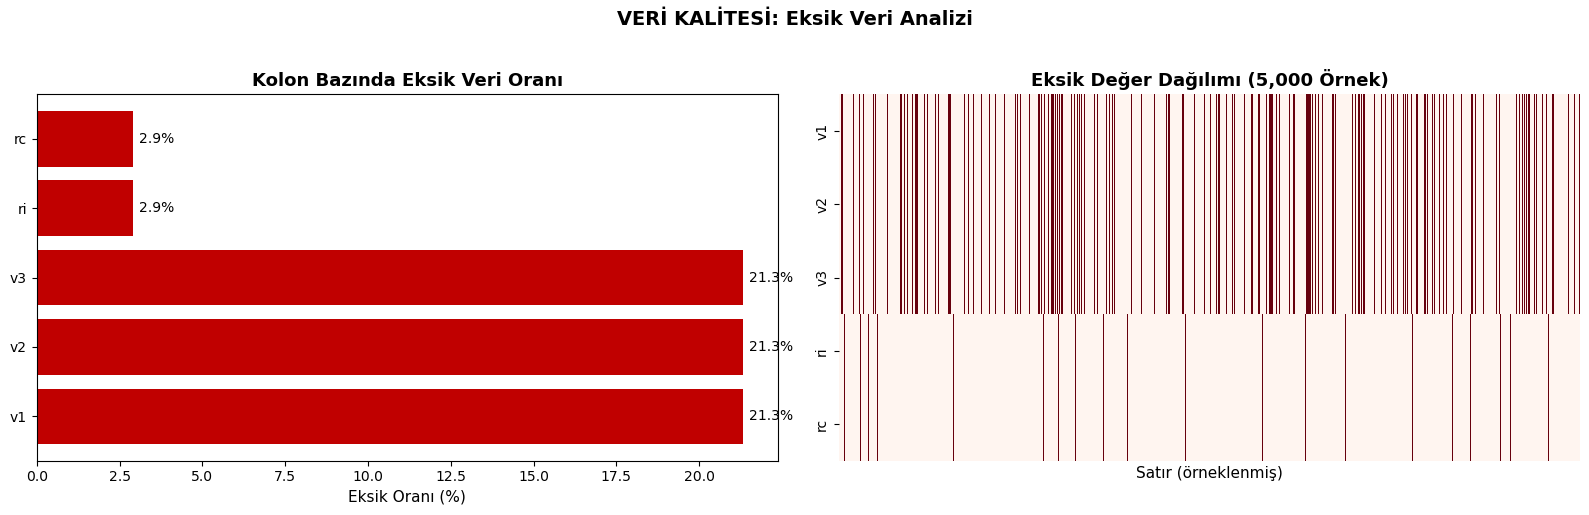

Görsel kaydedildi: outputs/eda/missing_analysis.png


In [33]:
miss_cols = miss_pct.index.tolist()
if miss_cols:
    sample_miss = df_raw[miss_cols].isnull().astype(int)
    if len(sample_miss) > 5000:
        sample_miss = sample_miss.sample(5000, random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].barh(miss_pct.index, miss_pct.values, color=PALETTE[2])
    axes[0].set_xlabel('Eksik Oranı (%)')
    axes[0].set_title('Kolon Bazında Eksik Veri Oranı', fontweight='bold')
    for i, v in enumerate(miss_pct.values):
        axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)

    sns.heatmap(sample_miss.T, cmap='Reds', cbar=False,
                xticklabels=False, ax=axes[1])
    axes[1].set_title('Eksik Değer Dağılımı (5,000 Örnek)', fontweight='bold')
    axes[1].set_xlabel('Satır (örneklenmiş)')

    plt.suptitle('VERİ KALİTESİ: Eksik Veri Analizi', fontweight='bold',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(EDA_OUT / 'missing_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Görsel kaydedildi: outputs/eda/missing_analysis.png')

In [34]:
df_raw['v_missing'] = df_raw[['v1','v2','v3']].isnull().any(axis=1).astype(int)

miss_by_ilce = (
    df_raw.groupby(['il', 'ilce'])['v_missing']
    .agg(['sum', 'mean'])
    .rename(columns={'sum': 'eksik_kayit', 'mean': 'eksik_oran'})
    .assign(eksik_oran=lambda x: (x['eksik_oran'] * 100).round(2))
    .sort_values('eksik_oran', ascending=False)
    .head(20)
)

print('Top 20 İlçe — Gerilim Eksik Oranı:')
display(miss_by_ilce)

Top 20 İlçe — Gerilim Eksik Oranı:


eksik_kayit  eksik_oran
il     ilce                               
SAMSUN Atakum             5859    100.0000
       Kavak              5846    100.0000
       Terme              5856    100.0000
AMASYA Merzifon          11589     88.9500
SAMSUN İlkadım           17563     75.3100
AMASYA Merkez             5855     57.1000
SAMSUN Bafra              5850     49.9700
SİNOP  Ayancık            5838     42.4400
       Merkez             5381     42.4400
ÇORUM  Merkez             5797     11.1400
SAMSUN Havza                 0      0.0000
ORDU   Gölköy                0      0.0000
       Altınordu             0      0.0000
       Fatsa                 0      0.0000
AMASYA Taşova                0      0.0000
       Hamamözü              0      0.0000
SAMSUN Vezırköprü            0      0.0000
       Salıpazarı            0      0.0000
SİNOP  Gerze                 0      0.0000
       Türkeli               0      0.0000

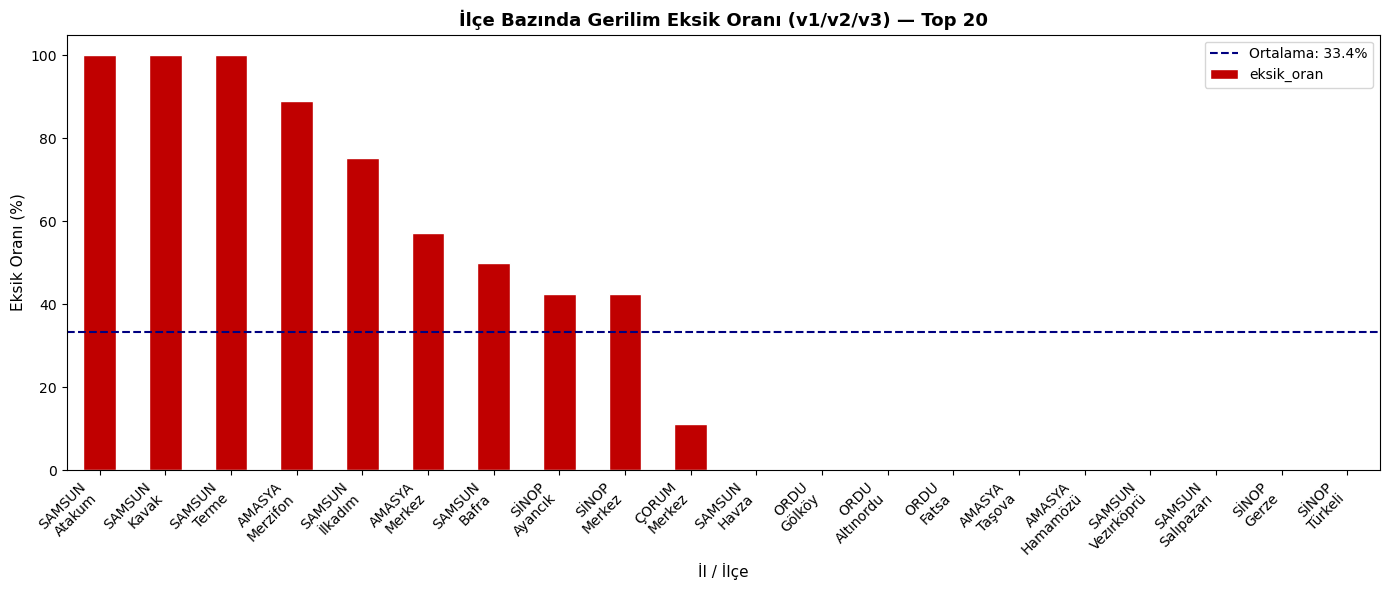

In [35]:
fig, ax = plt.subplots(figsize=(14, 6))
miss_by_ilce['eksik_oran'].plot(kind='bar', ax=ax, color=PALETTE[2], edgecolor='white')
ax.axhline(miss_by_ilce['eksik_oran'].mean(), color='navy', linestyle='--',
           label=f'Ortalama: {miss_by_ilce["eksik_oran"].mean():.1f}%')
ax.set_title('İlçe Bazında Gerilim Eksik Oranı (v1/v2/v3) — Top 20', fontweight='bold')
ax.set_xlabel('İl / İlçe')
ax.set_ylabel('Eksik Oranı (%)')
ax.legend()
ax.set_xticklabels([f"{r[0]}\n{r[1]}" for r in miss_by_ilce.index], rotation=45, ha='right')
plt.tight_layout()
plt.savefig(EDA_OUT / 'missing_by_ilce.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
neg_t0_df  = df_raw[df_raw['t0'] < 0]
zero_t0_df = df_raw[df_raw['t0'] == 0]

print(f't0 < 0  : {len(neg_t0_df):,} kayıt ({len(neg_t0_df)/len(df_raw)*100:.3f}%)')
print(f't0 == 0 : {len(zero_t0_df):,} kayıt ({len(zero_t0_df)/len(df_raw)*100:.3f}%)')

if len(neg_t0_df) > 0:
    print('\nNegatif t0 örneği:')
    display(neg_t0_df[['tesisat_no_id','il','ilce','t0','load_profile_date']].head(5))

t0 < 0  : 0 kayıt (0.000%)
t0 == 0 : 0 kayıt (0.000%)


In [37]:
dq_summary = pd.DataFrame({
    'kontrol': ['v1_v2_v3_missing', 't0_negatif', 't0_sifir',
                'v1_sifir', 'l1_sifir', 'l2_sifir', 'l3_sifir',
                'ri_missing', 'rc_missing'],
    'kayit_sayisi': [
        df_raw[['v1','v2','v3']].isnull().any(axis=1).sum(),
        (df_raw['t0'] < 0).sum(),
        (df_raw['t0'] == 0).sum(),
        (df_raw['v1'].fillna(-1) == 0).sum(),
        (df_raw['l1'] == 0).sum(),
        (df_raw['l2'] == 0).sum(),
        (df_raw['l3'] == 0).sum(),
        df_raw['ri'].isnull().sum(),
        df_raw['rc'].isnull().sum(),
    ]
})
dq_summary['oran_pct'] = (dq_summary['kayit_sayisi'] / len(df_raw) * 100).round(3)
dq_summary.to_csv(EDA_OUT / 'data_quality_summary.csv', index=False)
display(dq_summary)
print('data_quality_summary.csv kaydedildi')

,kontrol,kayit_sayisi,oran_pct
0,v1_v2_v3_missing,75434,21.3120
1,t0_negatif,0,0.0000
2,t0_sifir,0,0.0000
3,v1_sifir,4408,1.2450
4,l1_sifir,100216,28.3140
5,l2_sifir,34575,9.7680
6,l3_sifir,2423,0.6850
7,ri_missing,10240,2.8930
8,rc_missing,10240,2.8930


data_quality_summary.csv kaydedildi


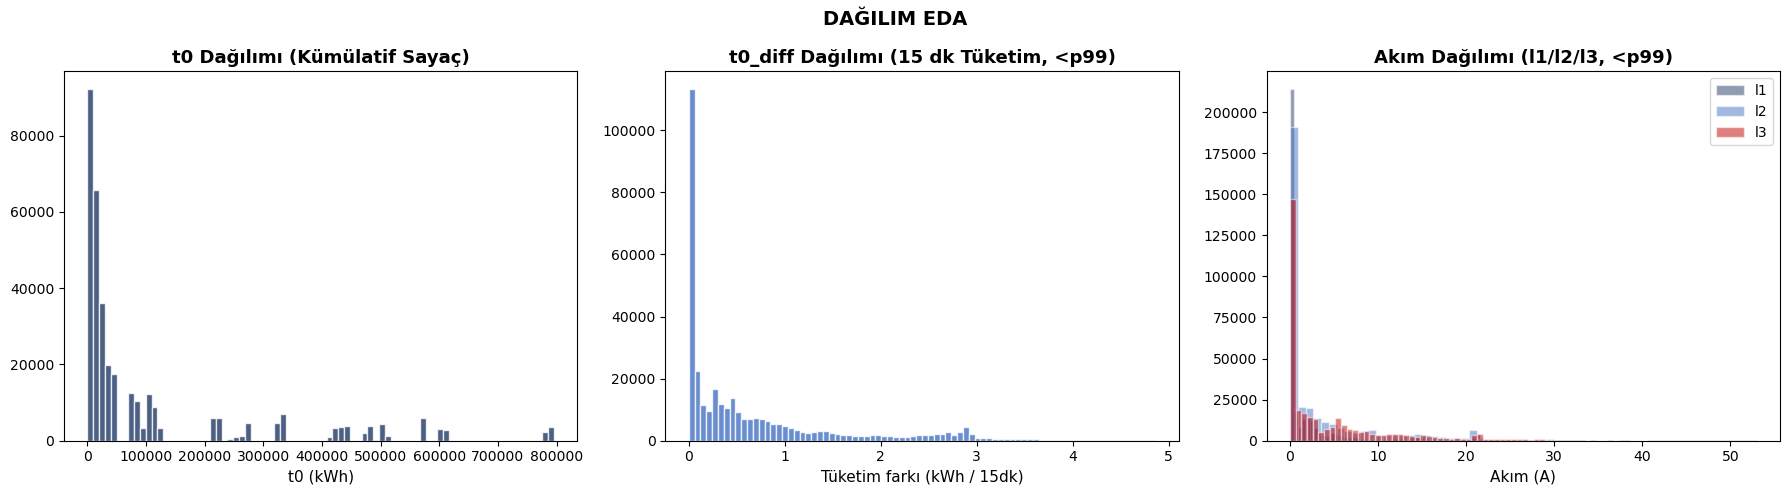

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_raw['t0'].dropna(), bins=80, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].set_title('t0 Dağılımı (Kümülatif Sayaç)', fontweight='bold')
axes[0].set_xlabel('t0 (kWh)')

t0_preview = df_raw.sort_values(['tesisat_no_id','load_profile_date'])
t0_preview['_t0_diff_raw'] = t0_preview.groupby('tesisat_no_id')['t0'].diff()
pos_diff = t0_preview['_t0_diff_raw'].dropna()
pos_diff = pos_diff[(pos_diff >= 0) & (pos_diff < pos_diff.quantile(0.99))]

axes[1].hist(pos_diff, bins=80, color=PALETTE[1], edgecolor='white', alpha=0.8)
axes[1].set_title('t0_diff Dağılımı (15 dk Tüketim, <p99)', fontweight='bold')
axes[1].set_xlabel('Tüketim farkı (kWh / 15dk)')

for col, color in zip(['l1','l2','l3'], PALETTE[:3]):
    vals = df_raw[col].dropna()
    vals = vals[vals < vals.quantile(0.99)]
    axes[2].hist(vals, bins=60, alpha=0.5, label=col, color=color, edgecolor='white')
axes[2].set_title('Akım Dağılımı (l1/l2/l3, <p99)', fontweight='bold')
axes[2].set_xlabel('Akım (A)')
axes[2].legend()

plt.suptitle('DAĞILIM EDA', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / 'distribution_eda.png', dpi=150, bbox_inches='tight')
plt.show()

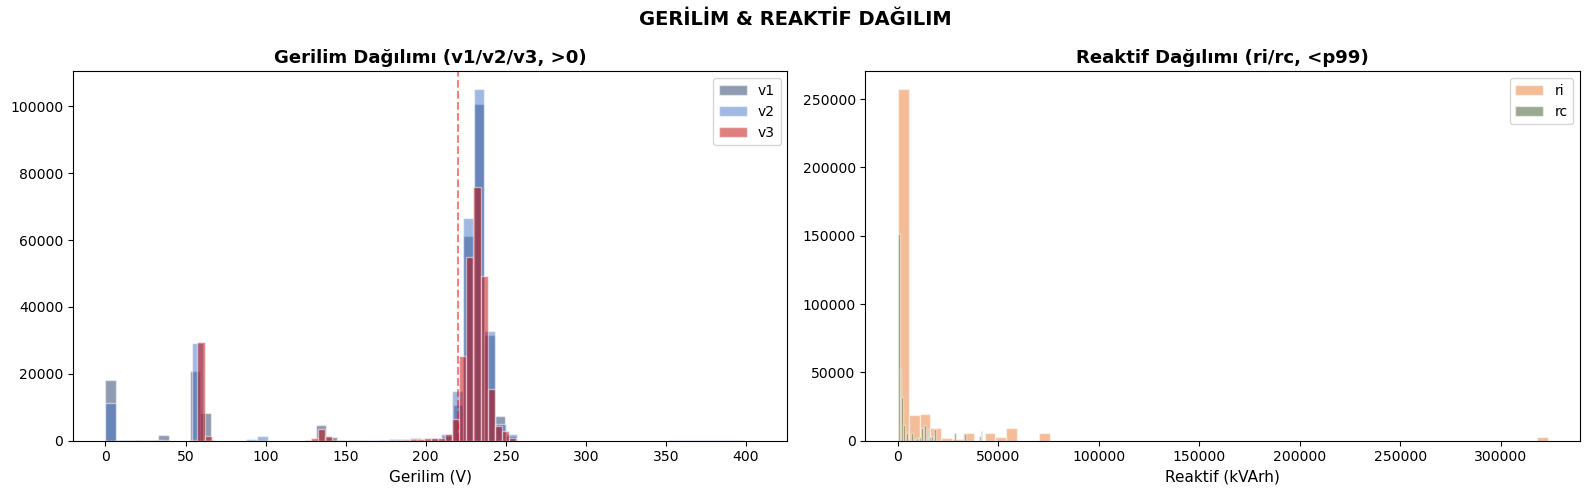

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col, color in zip(['v1','v2','v3'], PALETTE[:3]):
    vals = df_raw[col].dropna()
    vals = vals[vals > 0]
    axes[0].hist(vals, bins=60, alpha=0.5, label=col, color=color, edgecolor='white')
axes[0].set_title('Gerilim Dağılımı (v1/v2/v3, >0)', fontweight='bold')
axes[0].set_xlabel('Gerilim (V)')
axes[0].legend()
axes[0].axvline(220, color='red', linestyle='--', alpha=0.5, label='220V referans')

for col, color in zip(['ri','rc'], [PALETTE[3], PALETTE[4]]):
    vals = df_raw[col].dropna()
    vals = vals[vals < vals.quantile(0.99)]
    axes[1].hist(vals, bins=60, alpha=0.5, label=col, color=color, edgecolor='white')
axes[1].set_title('Reaktif Dağılımı (ri/rc, <p99)', fontweight='bold')
axes[1].set_xlabel('Reaktif (kVArh)')
axes[1].legend()

plt.suptitle('GERİLİM & REAKTİF DAĞILIM', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / 'voltage_reactive_dist.png', dpi=150, bbox_inches='tight')
plt.show()

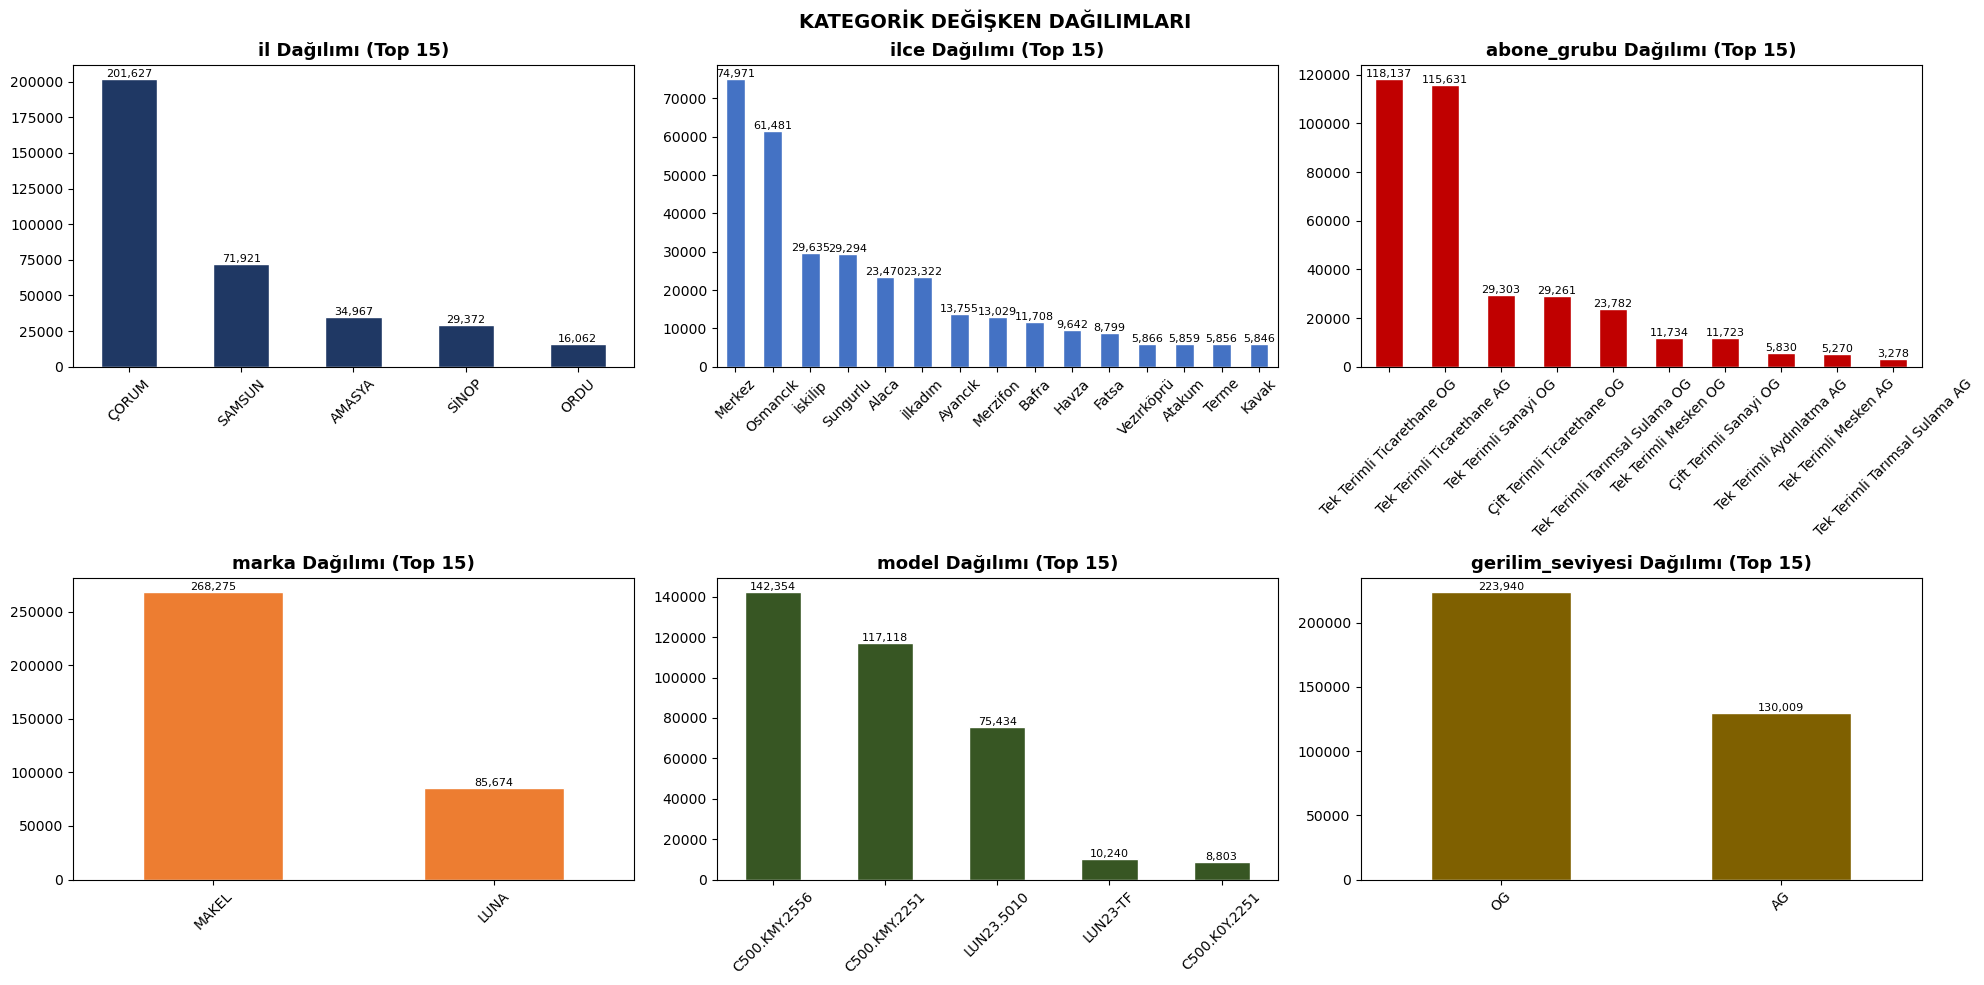

In [40]:
cat_cols = ['il', 'ilce', 'abone_grubu', 'marka', 'model', 'gerilim_seviyesi']
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if col in df_raw.columns:
        vc = df_raw[col].value_counts().head(15)
        vc.plot(kind='bar', ax=axes[i], color=PALETTE[i % len(PALETTE)], edgecolor='white')
        axes[i].set_title(f'{col} Dağılımı (Top 15)', fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height()):,}',
                            (p.get_x() + p.get_width()/2., p.get_height()),
                            ha='center', va='bottom', fontsize=8)

plt.suptitle('KATEGORİK DEĞİŞKEN DAĞILIMLARI', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / 'categorical_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
outlier_cols = ['l1', 'l2', 'l3', 't0', 'ri', 'rc']
outlier_records = []

for col in outlier_cols:
    if col not in df_raw.columns:
        continue
    p99 = df_raw[col].quantile(0.99)
    p01 = df_raw[col].quantile(0.01)
    outliers = df_raw[
        (df_raw[col] > p99) | ((df_raw[col] < p01) & (df_raw[col] >= 0))
    ][['tesisat_no_id','il','ilce',col,'load_profile_date']].copy()
    outliers['outlier_kolon']  = col
    outliers['outlier_deger']  = outliers[col]
    outliers['p99_esik']       = round(p99, 4)
    outliers['p01_esik']       = round(p01, 4)
    outliers = outliers.drop(columns=[col])
    outlier_records.append(outliers)

outlier_df = pd.concat(outlier_records, ignore_index=True)
outlier_df.to_csv(EDA_OUT / 'outlier_candidates.csv', index=False)
print(f'Aykırı değer adayı: {len(outlier_df):,} kayıt')
print('outlier_candidates.csv kaydedildi')
display(outlier_df.groupby('outlier_kolon').size().rename('aykiri_kayit_sayisi').to_frame())

Aykırı değer adayı: 27,946 kayıt
outlier_candidates.csv kaydedildi


,aykiri_kayit_sayisi
outlier_kolon,
l1,3540
l2,3540
l3,6910
rc,3438
ri,3438
t0,7080


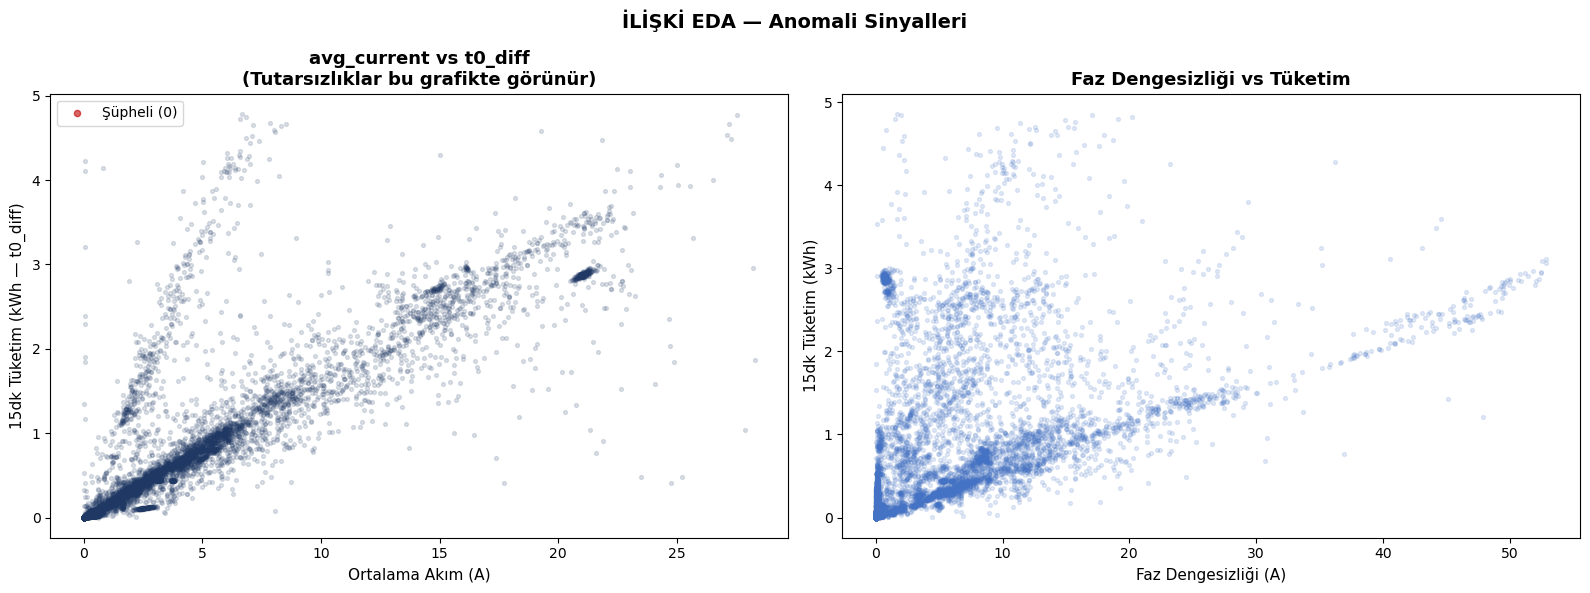

In [42]:
df_eda = df_raw.copy()
df_eda['avg_current'] = (df_eda['l1'] + df_eda['l2'] + df_eda['l3']) / 3
df_eda = df_eda.sort_values(['tesisat_no_id', 'load_profile_date'])
df_eda['t0_diff'] = df_eda.groupby('tesisat_no_id')['t0'].diff()

plot_data = df_eda.dropna(subset=['avg_current', 't0_diff'])
plot_data = plot_data[
    (plot_data['avg_current'] < plot_data['avg_current'].quantile(0.99)) &
    (plot_data['t0_diff'] >= 0) &
    (plot_data['t0_diff'] < plot_data['t0_diff'].quantile(0.99))
].sample(min(10000, len(plot_data)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(plot_data['avg_current'], plot_data['t0_diff'],
                alpha=0.15, color=PALETTE[0], s=8)
axes[0].set_xlabel('Ortalama Akım (A)')
axes[0].set_ylabel('15dk Tüketim (kWh — t0_diff)')
axes[0].set_title('avg_current vs t0_diff\n(Tutarsızlıklar bu grafikte görünür)', fontweight='bold')

high_cur = plot_data['avg_current'].quantile(0.90)
low_t0d  = plot_data['t0_diff'].quantile(0.10)
suspect  = plot_data[(plot_data['avg_current'] > high_cur) & (plot_data['t0_diff'] < low_t0d)]
axes[0].scatter(suspect['avg_current'], suspect['t0_diff'],
                alpha=0.6, color=PALETTE[2], s=20, label=f'Şüpheli ({len(suspect):,})')
axes[0].legend()

df_eda['phase_imbalance'] = (
    df_eda[['l1','l2','l3']].max(axis=1) - df_eda[['l1','l2','l3']].min(axis=1)
)
pi_data = df_eda[['phase_imbalance','t0_diff']].dropna()
pi_data = pi_data[
    (pi_data['phase_imbalance'] < pi_data['phase_imbalance'].quantile(0.99)) &
    (pi_data['t0_diff'] >= 0) &
    (pi_data['t0_diff'] < pi_data['t0_diff'].quantile(0.99))
].sample(min(10000, len(pi_data)), random_state=42)

axes[1].scatter(pi_data['phase_imbalance'], pi_data['t0_diff'],
                alpha=0.15, color=PALETTE[1], s=8)
axes[1].set_xlabel('Faz Dengesizliği (A)')
axes[1].set_ylabel('15dk Tüketim (kWh)')
axes[1].set_title('Faz Dengesizliği vs Tüketim', fontweight='bold')

plt.suptitle('İLİŞKİ EDA — Anomali Sinyalleri', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / 'relationship_eda.png', dpi=150, bbox_inches='tight')
plt.show()

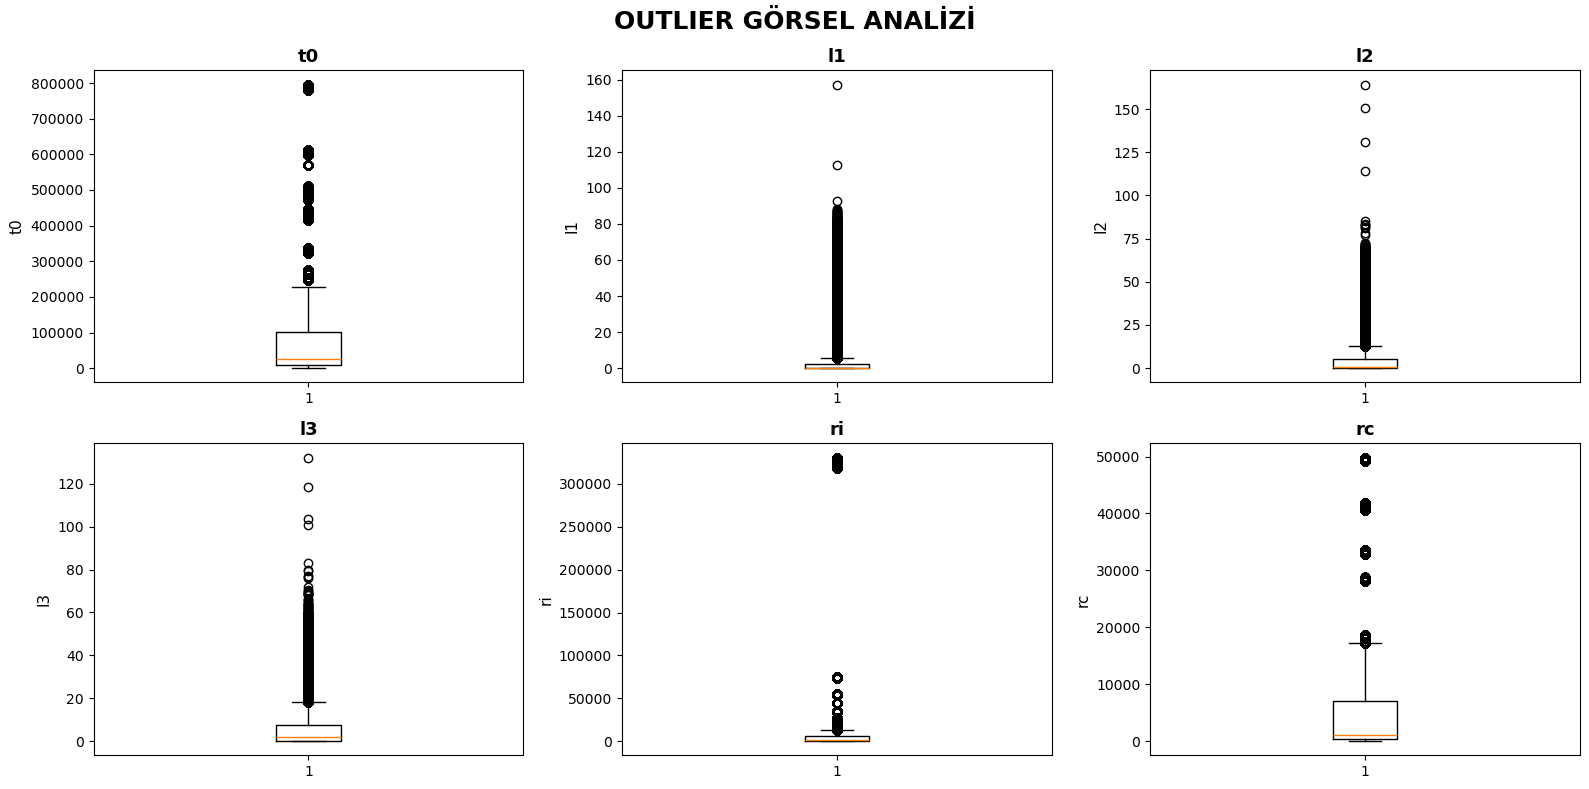

In [43]:
box_cols = ['t0','l1','l2','l3','ri','rc']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    if col not in df_raw.columns:
        continue
    vals = df_raw[col].dropna()
    axes[i].boxplot(vals)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('OUTLIER GÖRSEL ANALİZİ', fontweight='bold', fontsize=18)
plt.tight_layout()
plt.savefig(EDA_OUT / 'outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

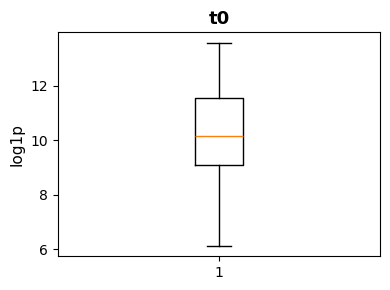

In [44]:
plt.figure(figsize=(4,3))

t0_log = np.log1p(df_raw['t0'].dropna())

plt.boxplot(t0_log)
plt.title('t0', fontweight='bold')
plt.ylabel('log1p')

plt.tight_layout()
plt.show()

## 5. Data Cleaning

In [45]:
df_clean = df_raw.copy()

required_cols = ['tesisat_no_id','load_profile_date','t0','l1','l2','l3','v1','v2','v3','ri','rc']
missing_required = [c for c in required_cols if c not in df_clean.columns]
if missing_required:
    raise ValueError(f"Eksik zorunlu kolon(lar): {missing_required}")

df_clean['load_profile_date'] = pd.to_datetime(df_clean['load_profile_date'], errors='coerce')

In [46]:
before = len(df_clean)
dup_mask = df_clean.duplicated(subset=['tesisat_no_id','load_profile_date'], keep='first')
dup_count = int(dup_mask.sum())
df_clean = df_clean.loc[~dup_mask].copy()
after = len(df_clean)

print(f"Duplicate kayıt (tesisat+tarih): {dup_count:,}  → silindi: {before-after:,} | yeni boyut: {after:,}")

Duplicate kayıt (tesisat+tarih): 0  → silindi: 0 | yeni boyut: 353,949


In [47]:
df_clean = df_clean.sort_values(['tesisat_no_id','load_profile_date']).reset_index(drop=True)
print("Tarih sıralaması tamamlandı.")

Tarih sıralaması tamamlandı.


In [48]:
df_clean['dq_flag_negative_t0'] = (df_clean['t0'] < 0).astype(int)
df_clean['dq_flag_zero_t0']     = (df_clean['t0'] == 0).astype(int)

df_clean['v_missing_flag']  = df_clean[['v1','v2','v3']].isnull().any(axis=1).astype(int)
df_clean['ri_missing_flag'] = df_clean['ri'].isnull().astype(int)
df_clean['rc_missing_flag'] = df_clean['rc'].isnull().astype(int)

df_clean['phase_zero_flag'] = (
    (df_clean['l1'] == 0) | (df_clean['l2'] == 0) | (df_clean['l3'] == 0)
).astype(int)

print("Flag'ler oluşturuldu.")
print(f"   Negatif t0 : {df_clean['dq_flag_negative_t0'].sum():,}")
print(f"   Sıfır t0   : {df_clean['dq_flag_zero_t0'].sum():,}")
print(f"   Voltaj eksik (v1/v2/v3 any NA): {df_clean['v_missing_flag'].sum():,} ({df_clean['v_missing_flag'].mean()*100:.2f}%)")
print(f"   Faz sıfır  : {df_clean['phase_zero_flag'].sum():,}")

Flag'ler oluşturuldu.
   Negatif t0 : 0
   Sıfır t0   : 0
   Voltaj eksik (v1/v2/v3 any NA): 75,434 (21.31%)
   Faz sıfır  : 108,077


In [49]:
assert df_clean['v_missing_flag'].sum() > 0, 'Flag kayboldu!'

In [50]:
for vcol in ['v1','v2','v3']:
    med = df_clean[vcol].median(skipna=True)
    df_clean[vcol] = df_clean[vcol].fillna(med)

df_clean['ri'] = df_clean['ri'].fillna(0)
df_clean['rc'] = df_clean['rc'].fillna(0)

print("Impute tamamlandı (v1/v2/v3=medyan, ri/rc=0). Flag'ler korundu.")

Impute tamamlandı (v1/v2/v3=medyan, ri/rc=0). Flag'ler korundu.


In [51]:
df_model_base = df_clean[df_clean['dq_flag_negative_t0'] == 0].copy()
print(f"df_model_base oluşturuldu (negatif t0 hariç): {len(df_model_base):,} kayıt | korunan: {len(df_model_base)/len(df_clean)*100:.2f}%")

df_model_base oluşturuldu (negatif t0 hariç): 353,949 kayıt | korunan: 100.00%


In [52]:
clean_summary = pd.DataFrame({
    "kontrol": [
        "duplicate_silindi",
        "negatif_t0",
        "sifir_t0",
        "voltage_missing_any",
        "phase_zero",
        "ri_missing",
        "rc_missing",
    ],
    "kayit_sayisi": [
        before-after,
        df_clean['dq_flag_negative_t0'].sum(),
        df_clean['dq_flag_zero_t0'].sum(),
        df_clean['v_missing_flag'].sum(),
        df_clean['phase_zero_flag'].sum(),
        df_clean['ri_missing_flag'].sum(),
        df_clean['rc_missing_flag'].sum(),
    ]
})
clean_summary["oran_pct"] = (clean_summary["kayit_sayisi"] / len(df_clean) * 100).round(3)

display(clean_summary)

,kontrol,kayit_sayisi,oran_pct
0,duplicate_silindi,0,0.0000
1,negatif_t0,0,0.0000
2,sifir_t0,0,0.0000
3,voltage_missing_any,75434,21.3120
4,phase_zero,108077,30.5350
5,ri_missing,10240,2.8930
6,rc_missing,10240,2.8930


In [53]:
df_clean.to_csv(PROC / "clean_base.csv", index=False)
df_model_base.to_csv(PROC / "model_base.csv", index=False)
clean_summary.to_csv(EDA_OUT / "cleaning_summary.csv", index=False)

print("Kaydedildi:")
print(f" {PROC/'clean_base.csv'}")
print(f" {PROC/'model_base.csv'}")
print(f" {EDA_OUT/'cleaning_summary.csv'}")

Kaydedildi:
 C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\Data\Processed\clean_base.csv
 C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\Data\Processed\model_base.csv
 C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\Outputs\EDA\cleaning_summary.csv


## 6. Feature Engineering

In [54]:
def make_features(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    df['avg_current'] = (df['l1'] + df['l2'] + df['l3']) / 3

    df['avg_voltage'] = (df['v1'] + df['v2'] + df['v3']) / 3

    df['phase_imbalance'] = (
        df[['l1','l2','l3']].max(axis=1) - df[['l1','l2','l3']].min(axis=1)
    )

    df = df.sort_values(['tesisat_no_id', 'load_profile_date'])
    df['t0_diff'] = df.groupby('tesisat_no_id')['t0'].diff()
    df['t0_diff'] = df['t0_diff'].fillna(0)

    global_avg_v = df['avg_voltage'].mean()
    df['voltage_deviation'] = (df['avg_voltage'] / global_avg_v) - 1

    hour = df['load_profile_date'].dt.hour
    gs = CONFIG['GECE_START']
    ge = CONFIG['GECE_END']
    ms = CONFIG['MESAI_START']
    me = CONFIG['MESAI_END']

    df['time_bucket'] = np.where(
        (hour >= gs) & (hour < ge), 'Gece',
        np.where((hour >= ms) & (hour < me), 'Mesai', 'Gunduz')
    )

    df['phase_zero_flag'] = (
        (df['l1'] == 0) | (df['l2'] == 0) | (df['l3'] == 0)
    ).astype(int)

    df['voltage_missing_consumption_flag'] = (
        (df['v_missing_flag'] == 1) & (df['t0_diff'] > 0)
    ).astype(int)

    df['reactive_ratio'] = (df['ri'] + df['rc']) / (df['t0_diff'].abs() + 0.001)
    df['reactive_ratio'] = df['reactive_ratio'].clip(upper=df['reactive_ratio'].quantile(0.999))

    rolling_std = (
        df.groupby('tesisat_no_id')['t0_diff']
          .transform(lambda x: x.rolling(CONFIG['STEADY_WIN'], min_periods=3).std())
    )
    df['steady_consumption_flag'] = (rolling_std < CONFIG['STEADY_STD_THR']).astype(int)

    gece_df = df[df['time_bucket'] == 'Gece'].groupby('tesisat_no_id')['t0_diff'].sum()
    total_df = df.groupby('tesisat_no_id')['t0_diff'].sum()
    night_ratio_map = (gece_df / (total_df + 0.001)).to_dict()
    df['night_ratio'] = df['tesisat_no_id'].map(night_ratio_map).fillna(0)

    df['date_only']   = df['load_profile_date'].dt.date
    df['hour']        = df['load_profile_date'].dt.hour
    df['day_of_week'] = df['load_profile_date'].dt.dayofweek  # 0=Mon, 6=Sun
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

    return df

print('make_features() fonksiyonu tanımlandı ')

make_features() fonksiyonu tanımlandı 


In [55]:
df_feat = make_features(df_model_base)

print(f'Feature engineering sonrası: {df_feat.shape}')
new_cols = [c for c in df_feat.columns if c not in df_model_base.columns]
print(f'Yeni eklenen {len(new_cols)} kolon: {new_cols}')

display(df_feat[new_cols].describe().T.round(4))

Feature engineering sonrası: (353949, 40)
Yeni eklenen 14 kolon: ['avg_current', 'avg_voltage', 'phase_imbalance', 't0_diff', 'voltage_deviation', 'time_bucket', 'voltage_missing_consumption_flag', 'reactive_ratio', 'steady_consumption_flag', 'night_ratio', 'date_only', 'hour', 'day_of_week', 'is_weekend']


,count,mean,std,min,25%,50%,75%,max
avg_current,353949.0000,4.2562,6.2288,0.0000,0.1833,2.0027,5.2333,140.0967
avg_voltage,353949.0000,206.5247,56.2567,0.0000,225.3533,230.1800,232.7567,263.8200
phase_imbalance,353949.0000,5.5053,9.5336,0.0000,0.0480,1.1300,7.5100,114.1900
t0_diff,353949.0000,0.7518,1.0615,0.0000,0.0180,0.3170,0.9880,65.9640
voltage_deviation,353949.0000,-0.0000,0.2724,-1.0000,0.0912,0.1145,0.1270,0.2774
voltage_missing_consumption_flag,353949.0000,0.2129,0.4093,0.0000,0.0000,0.0000,0.0000,1.0000
reactive_ratio,353949.0000,285357.5642,982758.6596,0.0000,8165.2338,25758.4073,116145.8915,14331326.8123
steady_consumption_flag,353949.0000,0.9480,0.2219,0.0000,1.0000,1.0000,1.0000,1.0000
night_ratio,353949.0000,0.2026,0.0933,0.0000,0.1546,0.2107,0.2517,0.5396
hour,353949.0000,11.4925,6.9276,0.0000,5.0000,11.0000,18.0000,23.0000


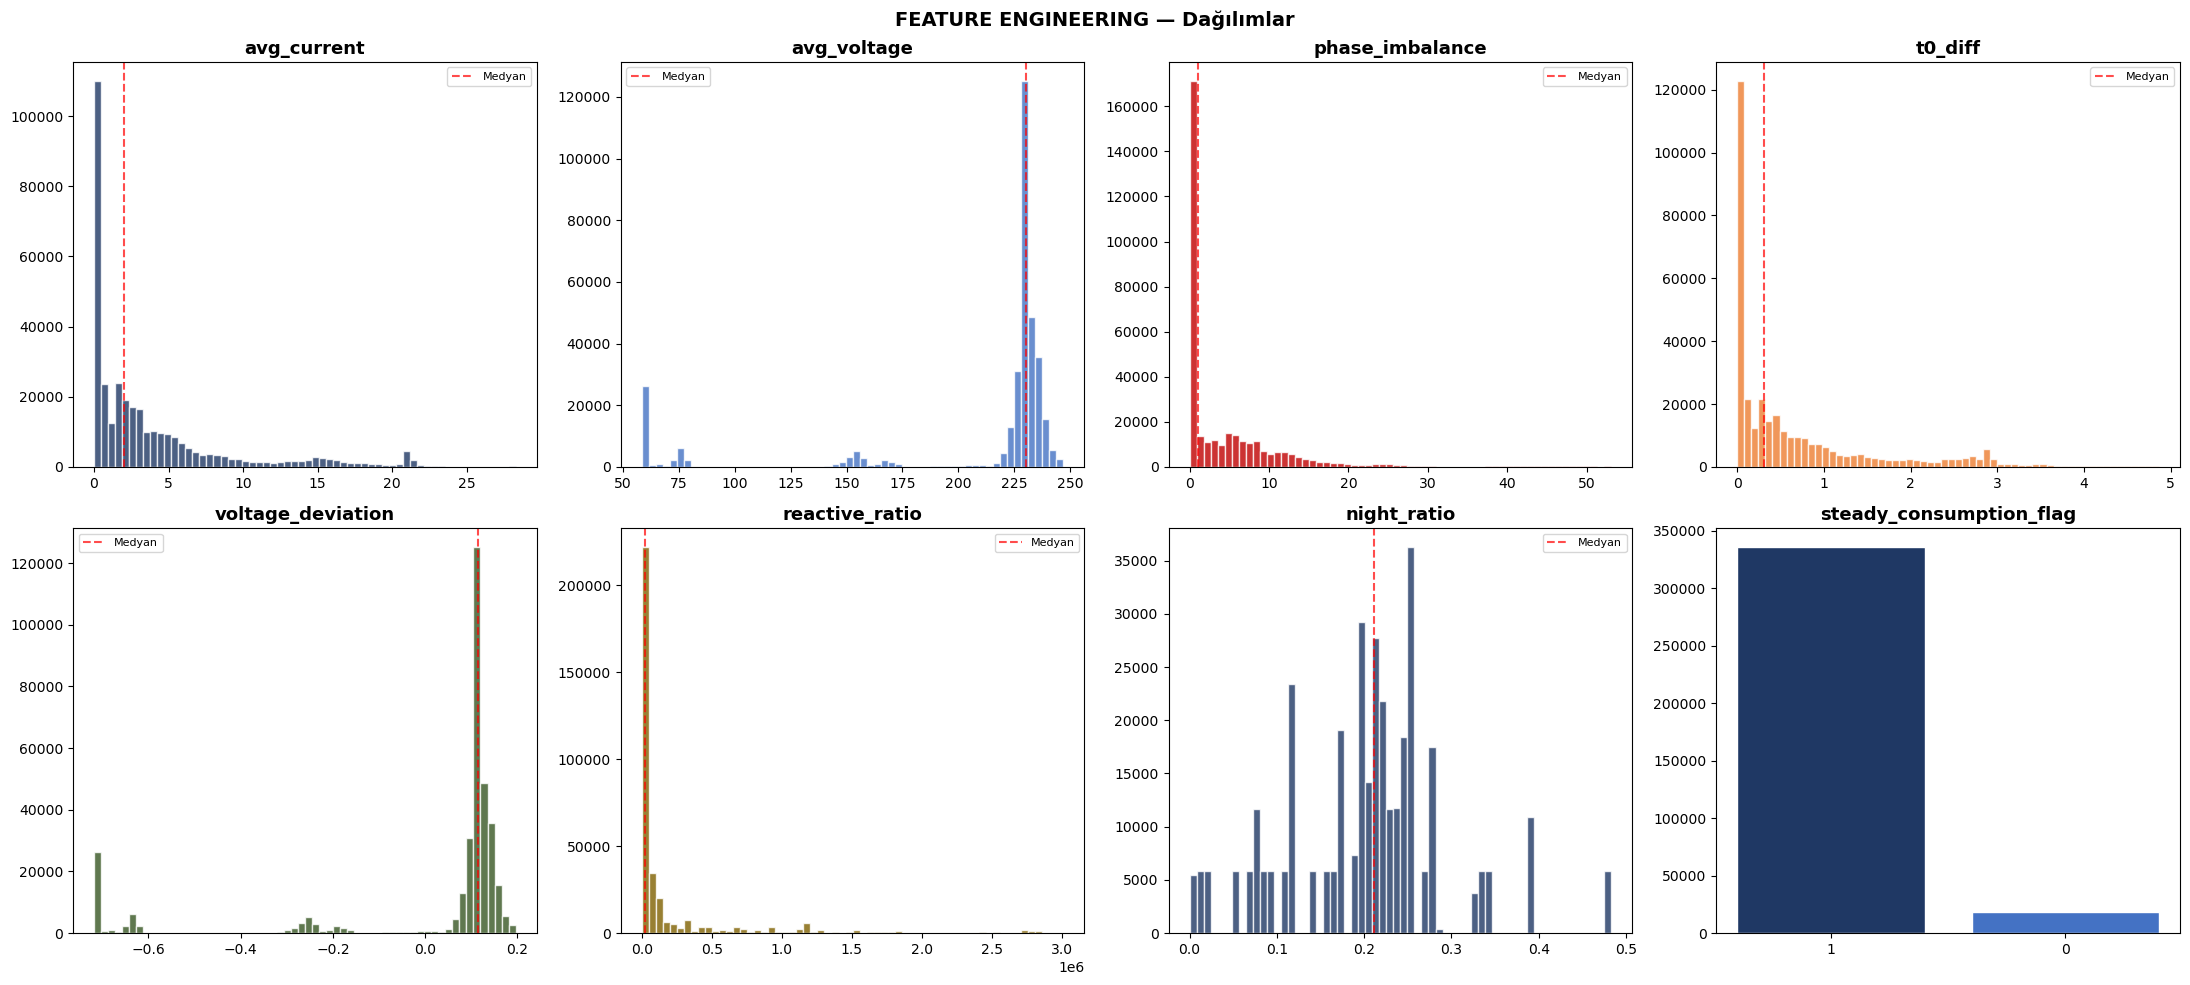

features.csv kaydedildi


In [56]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

vis_feats = ['avg_current', 'avg_voltage', 'phase_imbalance', 't0_diff',
             'voltage_deviation', 'reactive_ratio', 'night_ratio', 'steady_consumption_flag']

for i, feat in enumerate(vis_feats):
    if feat == 'steady_consumption_flag':
        vc = df_feat[feat].value_counts()
        axes[i].bar(vc.index.astype(str), vc.values, color=PALETTE[:len(vc)], edgecolor='white')
        axes[i].set_title(feat, fontweight='bold')
        continue
    vals = df_feat[feat].dropna()
    vals = vals[(vals >= vals.quantile(0.01)) & (vals <= vals.quantile(0.99))]
    axes[i].hist(vals, bins=60, color=PALETTE[i % len(PALETTE)], edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].axvline(vals.median(), color='red', linestyle='--', alpha=0.7, label='Medyan')
    axes[i].legend(fontsize=8)

plt.suptitle('FEATURE ENGINEERING — Dağılımlar', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

df_feat.to_csv(PROC / 'features.csv', index=False)
print('features.csv kaydedildi')

## 7.Anomaly Rules & Risk Score

In [57]:
df_feat = df_feat.copy()

pos_t0_diff = df_feat.loc[df_feat['t0_diff'] > 0, 't0_diff'].dropna()

if len(pos_t0_diff) == 0:
    pos_t0_diff = df_feat['t0_diff'].abs().replace(0, np.nan).dropna()

MEDIAN_T0 = float(pos_t0_diff.median())   if len(pos_t0_diff) else 0.0
LOW_T0    = float(pos_t0_diff.quantile(0.05)) if len(pos_t0_diff) else 0.0

CONFIG['HIGH_CURRENT']    = float(df_feat['avg_current'].quantile(0.90))
CONFIG['LOW_CURRENT']     = float(df_feat['avg_current'].quantile(0.10))
CONFIG['HIGH_CURRENT_75'] = float(df_feat['avg_current'].quantile(0.75))
CONFIG['MEDIAN_T0_DIFF']  = MEDIAN_T0
CONFIG['LOW_T0_DIFF']     = LOW_T0
CONFIG['HIGH_IMBALANCE']  = float(df_feat['phase_imbalance'].quantile(0.90))
CONFIG['HIGH_REACTIVE']   = float(df_feat['reactive_ratio'].quantile(0.90))

print("Hesaplanan Eşikler:")
for k, v in CONFIG.items():
    if v is not None and isinstance(v, float):
        print(f"   {k:25s}: {v:.6f}")

Hesaplanan Eşikler:
   HIGH_CURRENT             : 13.350000
   LOW_CURRENT              : 0.013667
   LOW_T0_DIFF              : 0.002000
   HIGH_IMBALANCE           : 14.220000
   HIGH_REACTIVE            : 836443.299915
   STEADY_STD_THR           : 0.500000
   HIGH_CURRENT_75          : 5.233333
   MEDIAN_T0_DIFF           : 0.365000


In [58]:
def pct_rank_score(series: pd.Series, q: float, weight: float) -> pd.Series:

    thr = float(series.quantile(q)) + 1e-9
    return (series / thr).clip(0, 1) * weight

In [59]:
def score_risk(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    kacak_mask = (
        (df['avg_current'] > CONFIG['HIGH_CURRENT']) &
        (df['t0_diff']     < CONFIG['LOW_T0_DIFF'])
    )

    sayac_mask = (
        (df['t0_diff']     > CONFIG['MEDIAN_T0_DIFF']) &
        (df['avg_current'] < CONFIG['LOW_CURRENT'])
    )

    ekipman_mask = (
        (df['phase_imbalance'] > CONFIG['HIGH_IMBALANCE']) &
        (df['avg_current']     > CONFIG['HIGH_CURRENT_75'])
    )

    conditions = [kacak_mask, ekipman_mask, sayac_mask]
    choices    = ['kacak', 'ekipman_ariza', 'sayac_hatasi']
    df['anomaly_type'] = np.select(conditions, choices, default='normal')

    score_current   = pct_rank_score(df['avg_current'],     0.90, 40)
    score_imbalance = pct_rank_score(df['phase_imbalance'], 0.90, 30)
    score_reactive  = pct_rank_score(df['reactive_ratio'],  0.90, 20)
    score_phase_zero = df.get('phase_zero_flag', pd.Series(0, index=df.index)) * 10

    df['risk_score'] = (
        score_current + score_imbalance + score_reactive + score_phase_zero
    ).clip(0, 100).round(2)

    df.loc[
        (df['anomaly_type'] == 'normal') & (df['risk_score'] >= 40),
        'anomaly_type'
    ] = 'suspicious'

    df['risk_bucket'] = pd.cut(
        df['risk_score'],
        bins=[-1, 30, 60, 101],
        labels=['Low', 'Medium', 'High']
    )

    reason_map = {
        'kacak'        : 'Akım yüksek, tüketim düşük. Olası kaçak kullanım.',
        'ekipman_ariza': 'Faz dengesizliği ve yüksek akım. Ekipman arıza riski.',
        'sayac_hatasi' : 'Tüketim yüksek, akım düşük. Sayaç hatası ihtimali.',
        'suspicious'   : 'Kural tetiklenmedi ancak risk skoru yüksek. İnceleme önerilir.',
        'normal'       : 'Normal ölçüm aralığında.',
    }
    df['risk_reason'] = df['anomaly_type'].map(reason_map).fillna("")

    if 'phase_zero_flag' in df.columns:
        df.loc[df['phase_zero_flag'] == 1, 'risk_reason'] += ' Ayrıca faz akımı sıfır.'

    if 'voltage_missing_consumption_flag' in df.columns:
        df.loc[df['voltage_missing_consumption_flag'] == 1, 'risk_reason'] += ' Gerilim eksik ama tüketim devam ediyor.'

    return df

df_scored = score_risk(df_feat)

print("\nAnomali Dağılımı:")
anom_dist = df_scored['anomaly_type'].value_counts()
anom_pct  = df_scored['anomaly_type'].value_counts(normalize=True) * 100
display(pd.concat([anom_dist, anom_pct.round(4)], axis=1, keys=['Kayıt', 'Oran %']))

print("\nRisk Bucket Dağılımı:")
display(df_scored['risk_bucket'].value_counts())


Anomali Dağılımı:


,Kayıt,Oran %
anomaly_type,,
normal,260711,73.6578
suspicious,59251,16.7400
ekipman_ariza,33876,9.5709
sayac_hatasi,103,0.0291
kacak,8,0.0023



Risk Bucket Dağılımı:


risk_bucket
Low       215326
Medium    108253
High       30370
Name: count, dtype: int64

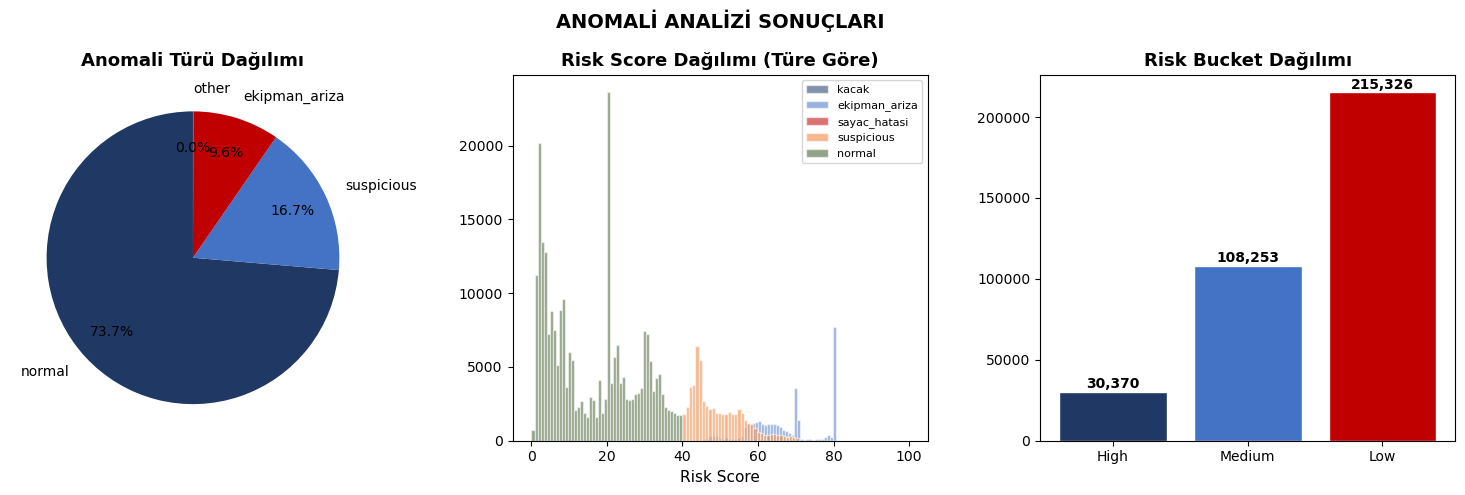

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

anom_pct = df_scored['anomaly_type'].value_counts(normalize=True) * 100
threshold = 1

small = anom_pct[anom_pct < threshold].sum()
large = anom_pct[anom_pct >= threshold].copy()

if small > 0:
    large.loc['other'] = small

axes[0].pie(
    large.values,
    labels=large.index,
    autopct='%1.1f%%',
    colors=PALETTE[:len(large)],
    startangle=90,
    pctdistance=0.75,
    labeldistance=1.15
)
axes[0].set_title('Anomali Türü Dağılımı', fontweight='bold')

plot_order = ['kacak', 'ekipman_ariza', 'sayac_hatasi', 'suspicious', 'normal']

for i, atype in enumerate(plot_order):
    subset = df_scored.loc[df_scored['anomaly_type'] == atype, 'risk_score']
    if len(subset) > 0:
        axes[1].hist(subset, bins=50, alpha=0.55, label=atype,
                     color=PALETTE[i % len(PALETTE)], edgecolor='white')

axes[1].set_title('Risk Score Dağılımı (Türe Göre)', fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].legend(fontsize=8)

rb = df_scored['risk_bucket'].value_counts().reindex(['High', 'Medium', 'Low'])
bars = axes[2].bar(rb.index.astype(str), rb.values,
                   color=PALETTE[:len(rb)], edgecolor='white')
axes[2].set_title('Risk Bucket Dağılımı', fontweight='bold')

for bar, v in zip(bars, rb.values):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        v + max(rb.values) * 0.01,
        f'{int(v):,}',
        ha='center',
        fontweight='bold',
    )

plt.suptitle('ANOMALİ ANALİZİ SONUÇLARI', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(EDA_OUT / 'anomaly_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
df_scored.sort_values("risk_score", ascending=False)[
    ["tesisat_no_id","il","ilce","risk_score","risk_bucket","anomaly_type","t0_diff","avg_current","phase_imbalance","reactive_ratio"]
].head(10)

,tesisat_no_id,il,ilce,risk_score,risk_bucket,anomaly_type,t0_diff,avg_current,phase_imbalance,reactive_ratio
266126,d7a38b85cd1c4238a10bd6182d8978b1,SAMSUN,Havza,100.0000,High,kacak,0.0000,13.9900,41.9600,10840388.0000
32226,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,100.0000,High,kacak,0.0000,21.5600,64.6700,3049786.0000
130083,79567eafb552482e9d30cbd74eb5a67b,SİNOP,Ayancık,90.0000,High,kacak,0.0000,14.7000,20.0000,3809958.0000
173458,a25e6e8c19b14740808305465b1de6c0,SAMSUN,Bafra,85.4700,High,ekipman_ariza,0.0000,8.5000,25.5000,1797669.0000
271930,d7a38b85cd1c4238a10bd6182d8978b1,SAMSUN,Havza,85.1400,High,ekipman_ariza,0.0510,18.8533,56.5500,215146.0384
215474,b4f5c124eae64882a39d56433599fddf,SİNOP,Ayancık,85.0300,High,ekipman_ariza,0.1040,10.6800,32.0300,545088.0762
168244,a23c33edc72545d38ef155de54d3588a,AMASYA,Taşova,83.1700,High,ekipman_ariza,0.0020,7.7333,23.1900,5082390.6783
135921,7c69a45825ae4dd68cfa3550f4ea7190,ÇORUM,Sungurlu,82.7200,High,suspicious,0.0000,10.9633,14.1600,14331326.8123
71514,4260d3390eb54089868310e7daefbaf3,SAMSUN,Vezırköprü,82.5500,High,ekipman_ariza,0.1640,18.5900,37.9600,106601.0242
32839,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,82.1500,High,ekipman_ariza,0.0330,17.7900,53.3500,89856.1177


In [62]:
df_scored.to_csv(PROC / 'final_dataset.csv', index=False)
print(f"\nfinal_dataset.csv kaydedildi → {len(df_scored):,} kayıt, {df_scored.shape[1]} kolon")
print(f"Görsel : {EDA_OUT / 'anomaly_results.png'}")


final_dataset.csv kaydedildi → 353,949 kayıt, 44 kolon
Görsel : C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\Outputs\EDA\anomaly_results.png


## 8. SQL Pivots

In [63]:
def build_pivots(df: pd.DataFrame):

    conn = sqlite3.connect(SQL_DIR / "proje3.db")
    df.to_sql('final_dataset', conn, if_exists='replace', index=False)
    print('SQLite: final_dataset yüklendi')

    pivots = {}

    #P1: Anomali Türü Dağılımı
    q_p1 = """
        SELECT
            anomaly_type,
            COUNT(*) AS kayit_sayisi,
            ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS oran_pct,
            ROUND(AVG(risk_score), 2) AS ort_risk_score
        FROM final_dataset
        GROUP BY anomaly_type
        ORDER BY kayit_sayisi DESC
    """
    pivots['pvt_anomaly_type'] = pd.read_sql(q_p1, conn)

    #P2: İl/İlçe Bazında Anomali
    q_p2 = """
        SELECT
            il, ilce,
            COUNT(*) AS toplam_kayit,
            SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) AS anomali_kayit,
            ROUND(SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS anomali_oran_pct,
            ROUND(AVG(risk_score), 2) AS ort_risk_score,
            SUM(CASE WHEN anomaly_type='kacak' THEN 1 ELSE 0 END) AS kacak_sayisi,
            SUM(CASE WHEN anomaly_type='ekipman_ariza' THEN 1 ELSE 0 END) AS ekipman_sayisi,
            SUM(CASE WHEN anomaly_type='sayac_hatasi' THEN 1 ELSE 0 END) AS sayac_sayisi,
            SUM(CASE WHEN anomaly_type='suspicious' THEN 1 ELSE 0 END) AS sup_sayisi
        FROM final_dataset
        GROUP BY il, ilce
        ORDER BY ort_risk_score DESC
    """
    pivots['pvt_il_ilce'] = pd.read_sql(q_p2, conn)

    #P3: Günlük Anomali Trendi
    q_p3 = """
        SELECT
            DATE(load_profile_date) AS date_only,
            COUNT(*) AS toplam_kayit,
            SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) AS anomali_sayisi,
            ROUND(AVG(risk_score), 2) AS ort_risk_score,
            SUM(CASE WHEN anomaly_type='kacak' THEN 1 ELSE 0 END) AS kacak,
            SUM(CASE WHEN anomaly_type='ekipman_ariza' THEN 1 ELSE 0 END) AS ekipman,
            SUM(CASE WHEN anomaly_type='sayac_hatasi' THEN 1 ELSE 0 END) AS sayac,
            SUM(CASE WHEN anomaly_type='suspicious' THEN 1 ELSE 0 END) AS suspicious
        FROM final_dataset
        GROUP BY DATE(load_profile_date)
        ORDER BY DATE(load_profile_date)
    """
    pivots['pvt_daily_trend'] = pd.read_sql(q_p3, conn)

    #P4: Top 10 Riskli Tesisat
    q_p4 = """
        SELECT
            tesisat_no_id,
            MAX(il) AS il,
            MAX(ilce) AS ilce,
            anomaly_type,
            ROUND(MAX(risk_score), 2) AS max_risk_score,
            ROUND(AVG(risk_score), 2) AS ort_risk_score,
            COUNT(*) AS anomali_kayit_sayisi,
            MAX(risk_reason) AS risk_reason,
            MAX(abone_grubu) AS abone_grubu,
            MAX(marka) AS marka,
            MAX(model) AS model
        FROM final_dataset
        WHERE anomaly_type NOT IN ('normal')
        GROUP BY tesisat_no_id, anomaly_type
        ORDER BY ort_risk_score DESC
        LIMIT 10
    """
    pivots['pvt_top10'] = pd.read_sql(q_p4, conn)

    #P5: Abone Grubu Risk Profili
    q_p5 = """
        SELECT
            abone_grubu,
            COUNT(*) AS toplam_kayit,
            SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) AS anomali_kayit,
            ROUND(AVG(risk_score), 2) AS ort_risk_score,
            SUM(CASE WHEN anomaly_type='kacak' THEN 1 ELSE 0 END) AS kacak_sayisi,
            SUM(CASE WHEN risk_bucket='High' THEN 1 ELSE 0 END) AS yuksek_risk_sayisi
        FROM final_dataset
        GROUP BY abone_grubu
        ORDER BY ort_risk_score DESC
    """
    pivots['pvt_abone_grubu'] = pd.read_sql(q_p5, conn)

    #P6: Sayaç Marka/Model
    q_p6 = """
        SELECT
            marka, model,
            COUNT(*) AS toplam_kayit,
            ROUND(AVG(risk_score), 2) AS ort_risk_score,
            SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) AS anomali_kayit,
            ROUND(SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS anomali_oran_pct
        FROM final_dataset
        GROUP BY marka, model
        ORDER BY anomali_oran_pct DESC
    """
    pivots['pvt_sayac_marka'] = pd.read_sql(q_p6, conn)

    #P7: Gece Anomalisi
    q_p7 = """
        SELECT
            tesisat_no_id, il, ilce,
            COUNT(*) AS gece_kayit,
            SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) AS gece_anomali,
            ROUND(AVG(t0_diff), 4) AS ort_gece_tuketim,
            ROUND(AVG(risk_score), 2) AS ort_risk
        FROM final_dataset
        WHERE time_bucket = 'Gece'
        GROUP BY tesisat_no_id, il, ilce
        HAVING gece_anomali > 0
        ORDER BY gece_anomali DESC
        LIMIT 50
    """
    pivots['pvt_gece_anomali'] = pd.read_sql(q_p7, conn)

    #P8: Sabit Tüketim
    q_p8 = """
        SELECT
            tesisat_no_id, il, ilce, abone_grubu,
            COUNT(*) AS sabit_tuketim_kayit,
            ROUND(AVG(t0_diff), 4) AS ort_tuketim,
            ROUND(AVG(risk_score), 2) AS ort_risk
        FROM final_dataset
        WHERE steady_consumption_flag = 1
        GROUP BY tesisat_no_id, il, ilce, abone_grubu
        ORDER BY sabit_tuketim_kayit DESC
        LIMIT 50
    """
    pivots['pvt_sabit_tuketim'] = pd.read_sql(q_p8, conn)

    #P9: Faz Sıfır
    q_p9 = """
        SELECT
            tesisat_no_id, il, ilce, marka, model, abone_grubu,
            SUM(phase_zero_flag) AS faz_sifir_kayit,
            COUNT(*) AS toplam_kayit,
            ROUND(SUM(phase_zero_flag) * 100.0 / COUNT(*), 2) AS faz_sifir_oran_pct
        FROM final_dataset
        GROUP BY tesisat_no_id, il, ilce, marka, model, abone_grubu
        HAVING faz_sifir_kayit > 0
        ORDER BY faz_sifir_kayit DESC
        LIMIT 50
    """
    pivots['pvt_faz_sifir'] = pd.read_sql(q_p9, conn)

    #P10: Gerilim Eksik Ama Tüketim Devam
    q_p10 = """
        SELECT
            tesisat_no_id, il, ilce,
            SUM(voltage_missing_consumption_flag) AS voltaj_eksik_tuketim_kayit,
            ROUND(AVG(t0_diff), 4) AS ort_tuketim,
            ROUND(AVG(risk_score), 2) AS ort_risk
        FROM final_dataset
        WHERE voltage_missing_consumption_flag = 1
        GROUP BY tesisat_no_id, il, ilce
        ORDER BY voltaj_eksik_tuketim_kayit DESC
        LIMIT 50
    """
    pivots['pvt_voltaj_eksik_tuketim'] = pd.read_sql(q_p10, conn)

    #P11: Negatif/Sıfır t0
    q_p11 = """
        SELECT
            il, ilce,
            SUM(dq_flag_negative_t0) AS negatif_t0_sayisi,
            SUM(dq_flag_zero_t0) AS sifir_t0_sayisi,
            COUNT(*) AS toplam_kayit
        FROM final_dataset
        GROUP BY il, ilce
        HAVING negatif_t0_sayisi + sifir_t0_sayisi > 0
        ORDER BY negatif_t0_sayisi DESC
    """
    pivots['pvt_negatif_sifir'] = pd.read_sql(q_p11, conn)

    #P12: Yüksek Reaktif – Düşük Aktif
    q_p12 = """
        SELECT
            tesisat_no_id, il, ilce, abone_grubu,
            ROUND(AVG(reactive_ratio), 4) AS ort_reaktif_oran,
            ROUND(AVG(t0_diff), 4) AS ort_tuketim,
            COUNT(*) AS kayit_sayisi
        FROM final_dataset
        GROUP BY tesisat_no_id, il, ilce, abone_grubu
        ORDER BY ort_reaktif_oran DESC
        LIMIT 30
    """
    pivots['pvt_reaktif_oran'] = pd.read_sql(q_p12, conn)

    #P13: Hafta içi/sonu
    q_p13 = """
        SELECT
            CASE WHEN is_weekend = 1 THEN 'Hafta Sonu' ELSE 'Hafta Ici' END AS gun_tipi,
            COUNT(*) AS toplam_kayit,
            ROUND(AVG(t0_diff), 4) AS ort_tuketim,
            ROUND(AVG(avg_current), 4) AS ort_akim,
            SUM(CASE WHEN anomaly_type NOT IN ('normal') THEN 1 ELSE 0 END) AS anomali_sayisi
        FROM final_dataset
        GROUP BY is_weekend
    """
    pivots['pvt_hafta_karsilastirma'] = pd.read_sql(q_p13, conn)

    conn.close()

    #CSV
    query_names = {
        'pvt_anomaly_type': q_p1,
        'pvt_il_ilce': q_p2,
        'pvt_daily_trend': q_p3,
        'pvt_top10': q_p4,
        'pvt_abone_grubu': q_p5,
        'pvt_sayac_marka': q_p6,
        'pvt_gece_anomali': q_p7,
        'pvt_sabit_tuketim': q_p8,
        'pvt_faz_sifir': q_p9,
        'pvt_voltaj_eksik_tuketim': q_p10,
        'pvt_negatif_sifir': q_p11,
        'pvt_reaktif_oran': q_p12,
        'pvt_hafta_karsilastirma': q_p13
    }

    for name, pivot_df in pivots.items():
        pivot_df.to_csv(PIV_OUT / f'{name}.csv', index=False)

    sql_content = '-- YEDAŞ Proje 3 — Pivot Sorguları\n-- final_dataset tablosu üzerinden çalışır\n\n'
    for name, query in query_names.items():
        sql_content += f'-- === {name} ===\n{query.strip()};\n\n'

    with open(SQL_DIR / 'pivots.sql', 'w', encoding='utf-8') as f:
        f.write(sql_content)

    print(f'{len(pivots)} pivot CSV kaydedildi → outputs/pivots/')
    print('pivots.sql kaydedildi → sql/pivots.sql')
    print(f'SQLite DB kaydedildi → {SQL_DIR / "proje3.db"}')

    return pivots

In [64]:
pivots = build_pivots(df_scored)

print('\n── pvt_anomaly_type ─────────────────────')
display(pivots['pvt_anomaly_type'])

print('\n── pvt_top10 ────────────────────────────')
display(pivots['pvt_top10'][['tesisat_no_id','il','ilce','anomaly_type',
                              'ort_risk_score','risk_reason']].head(10))

print('\n── pvt_il_ilce (Top 10) ─────────────────')
display(pivots['pvt_il_ilce'].head(10))

print('\n── pvt_daily_trend ─────────────────')
display(pivots['pvt_daily_trend'])

SQLite: final_dataset yüklendi
13 pivot CSV kaydedildi → outputs/pivots/
pivots.sql kaydedildi → sql/pivots.sql
SQLite DB kaydedildi → C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\SQL\proje3.db

── pvt_anomaly_type ─────────────────────


,anomaly_type,kayit_sayisi,oran_pct,ort_risk_score
0,normal,260711,73.6600,15.8100
1,suspicious,59251,16.7400,49.2600
2,ekipman_ariza,33876,9.5700,67.2100
3,sayac_hatasi,103,0.0300,9.7200
4,kacak,8,0.0000,77.1200



── pvt_top10 ────────────────────────────


,tesisat_no_id,il,ilce,anomaly_type,ort_risk_score,risk_reason
0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,kacak,100.0000,"Akım yüksek, tüketim düşük. Olası kaçak kullan..."
1,d7a38b85cd1c4238a10bd6182d8978b1,SAMSUN,Havza,kacak,100.0000,"Akım yüksek, tüketim düşük. Olası kaçak kullan..."
2,79567eafb552482e9d30cbd74eb5a67b,SİNOP,Ayancık,kacak,90.0000,"Akım yüksek, tüketim düşük. Olası kaçak kullanım."
3,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,ekipman_ariza,79.9200,Faz dengesizliği ve yüksek akım. Ekipman arıza...
4,d7a38b85cd1c4238a10bd6182d8978b1,SAMSUN,Havza,ekipman_ariza,79.4000,Faz dengesizliği ve yüksek akım. Ekipman arıza...
5,b4f5c124eae64882a39d56433599fddf,SİNOP,Ayancık,ekipman_ariza,78.6700,Faz dengesizliği ve yüksek akım. Ekipman arıza...
6,a895b42f51f545468fb948b6c3890a44,ÇORUM,Sungurlu,kacak,77.7800,"Akım yüksek, tüketim düşük. Olası kaçak kullanım."
7,a895b42f51f545468fb948b6c3890a44,ÇORUM,Sungurlu,ekipman_ariza,70.5900,Faz dengesizliği ve yüksek akım. Ekipman arıza...
8,7c69a45825ae4dd68cfa3550f4ea7190,ÇORUM,Sungurlu,ekipman_ariza,70.0200,Faz dengesizliği ve yüksek akım. Ekipman arıza...
9,b8e3d862c2014fa390968be1a230bcc2,AMASYA,Merzifon,ekipman_ariza,69.5900,Faz dengesizliği ve yüksek akım. Ekipman arıza...



── pvt_il_ilce (Top 10) ─────────────────


,il,ilce,toplam_kayit,anomali_kayit,anomali_oran_pct,ort_risk_score,kacak_sayisi,ekipman_sayisi,sayac_sayisi,sup_sayisi
0,ORDU,Gölköy,5788,5771,99.7100,79.5700,1,5756,14,0
1,SAMSUN,Bafra,11708,10071,86.0200,54.6700,0,6794,2,3275
2,SİNOP,Gerze,1465,1220,83.2800,53.9400,0,457,1,762
3,SAMSUN,Vezırköprü,5866,5823,99.2700,52.0300,0,934,0,4889
4,AMASYA,Taşova,5838,4676,80.1000,47.8100,0,1869,0,2807
5,SAMSUN,Havza,9642,3117,32.3300,41.9400,1,2670,0,446
6,SİNOP,Ayancık,13755,5174,37.6200,40.4800,1,4124,1,1048
7,SAMSUN,Kavak,5846,2886,49.3700,39.8900,0,822,1,2063
8,SAMSUN,İlkadım,23322,9413,40.3600,38.2300,0,4935,6,4472
9,ÇORUM,Sungurlu,29294,14425,49.2400,37.3000,1,1953,2,12469



── pvt_daily_trend ─────────────────


,date_only,toplam_kayit,anomali_sayisi,ort_risk_score,kacak,ekipman,sayac,suspicious
0,2025-08-01,5490,1572,26.3900,7,547,1,1017
1,2025-08-02,5490,1516,26.2000,0,579,1,936
2,2025-08-03,5511,1476,26.6100,0,572,0,904
3,2025-08-04,5503,1715,27.2700,0,636,4,1075
4,2025-08-05,5462,1756,27.8000,0,697,3,1056
...,...,...,...,...,...,...,...,...
57,2025-09-27,5791,1321,25.0800,0,449,1,871
58,2025-09-28,5762,1209,24.4900,0,421,0,788
59,2025-09-29,5781,1348,25.2100,0,442,1,905
60,2025-09-30,5704,1354,25.5800,0,471,6,877


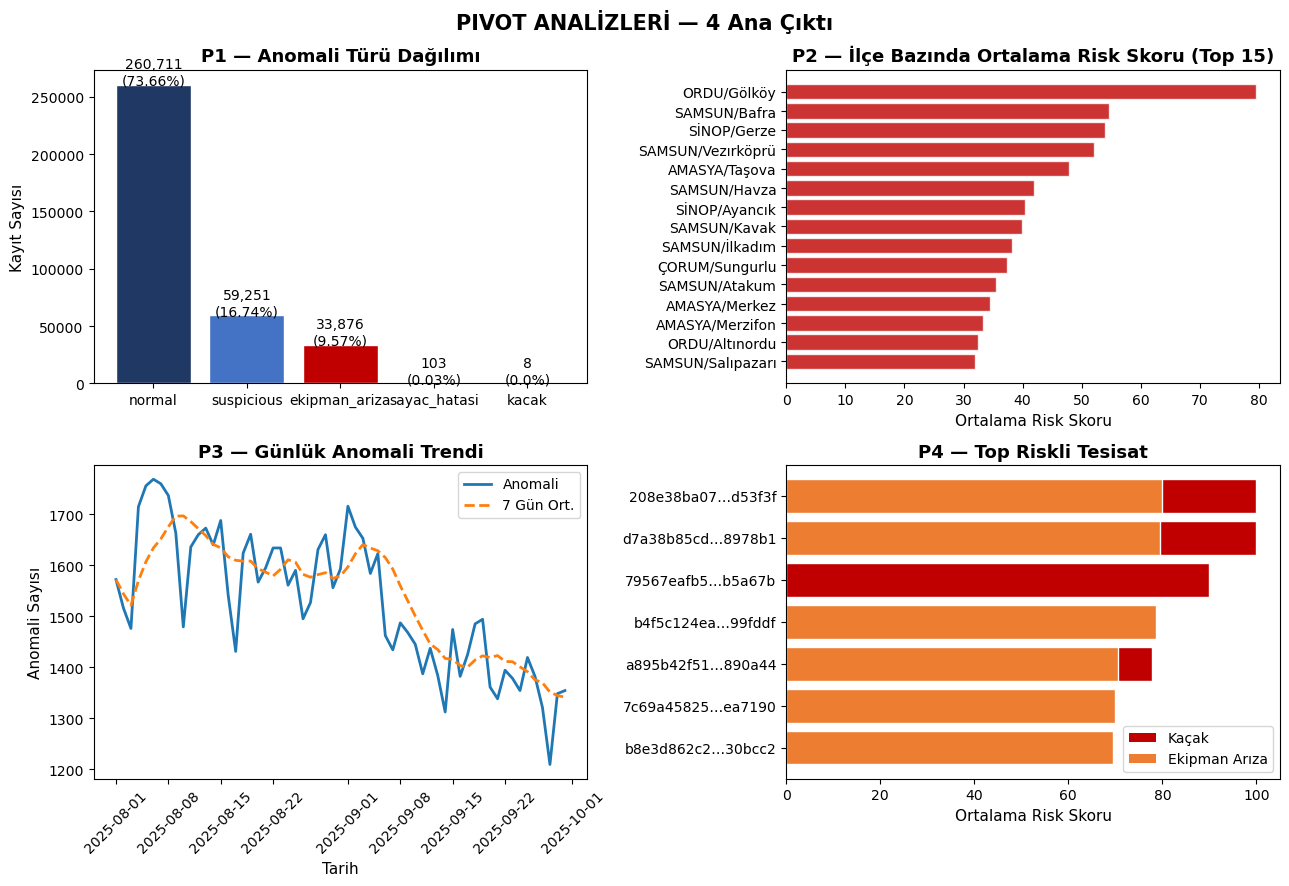

In [65]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

#P1
p1 = pivots['pvt_anomaly_type']
axes[0,0].bar(p1['anomaly_type'], p1['kayit_sayisi'],
              color=PALETTE[:len(p1)], edgecolor='white')
axes[0,0].set_title('P1 — Anomali Türü Dağılımı', fontweight='bold')
axes[0,0].set_ylabel('Kayıt Sayısı')
for i, v in enumerate(p1['kayit_sayisi']):
    axes[0,0].text(i, v + 100, f'{v:,}\n({p1["oran_pct"].iloc[i]}%)',
                   ha='center', fontsize=10)

# P2
p2 = pivots['pvt_il_ilce'].head(15)
labels = p2['il'] + '/' + p2['ilce']
bars = axes[0,1].barh(labels, p2['ort_risk_score'],
                       color=PALETTE[2], edgecolor='white', alpha=0.8)
axes[0,1].set_title('P2 — İlçe Bazında Ortalama Risk Skoru (Top 15)', fontweight='bold')
axes[0,1].set_xlabel('Ortalama Risk Skoru')
axes[0,1].invert_yaxis()

# P3
p3 = pivots['pvt_daily_trend'].copy()
p3['date_only'] = pd.to_datetime(p3['date_only'])
p3 = p3.sort_values('date_only')

p3 = p3.iloc[:-1]

p3['rolling_7'] = p3['anomali_sayisi'].rolling(7, min_periods=1).mean()

axes[1,0].plot(p3['date_only'], p3['anomali_sayisi'],
               linewidth=2, label='Anomali')
axes[1,0].plot(p3['date_only'], p3['rolling_7'],
               linewidth=2, linestyle='--', label='7 Gün Ort.')

axes[1,0].set_title('P3 — Günlük Anomali Trendi', fontweight='bold')
axes[1,0].set_xlabel('Tarih')
axes[1,0].set_ylabel('Anomali Sayısı')
axes[1,0].legend()
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)

# P4
p4 = pivots['pvt_top10'].copy()
p4 = p4.sort_values('ort_risk_score', ascending=False).head(10)

tes_short = (
    p4['tesisat_no_id'].astype(str).str[:10] + "…" +
    p4['tesisat_no_id'].astype(str).str[-6:]
)

labels = tes_short

color_map = {
    'kacak': PALETTE[2],
    'ekipman_ariza': PALETTE[3],
    'sayac_hatasi': PALETTE[1],
    'suspicious': PALETTE[0],
    'normal': '#CCCCCC',
}

colors = p4['anomaly_type'].map(color_map).fillna('#999999')

axes[1,1].barh(labels, p4['ort_risk_score'],
               color=colors, edgecolor='white')

axes[1,1].set_title('P4 — Top Riskli Tesisat', fontweight='bold')
axes[1,1].set_xlabel('Ortalama Risk Skoru')
axes[1,1].invert_yaxis()

label_map = {
    'kacak': 'Kaçak',
    'ekipman_ariza': 'Ekipman Arıza',
    'sayac_hatasi': 'Sayaç Hatası',
    'suspicious': 'Şüpheli',
    'normal': 'Normal'
}

types = p4['anomaly_type'].dropna().unique().tolist()
legend_elems = [
    Patch(facecolor=color_map.get(t, '#999999'), label=label_map.get(t, t))
    for t in types
]

axes[1,1].legend(handles=legend_elems, loc='lower right')

plt.suptitle('PIVOT ANALİZLERİ — 4 Ana Çıktı', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig(EDA_OUT / 'pivot_main_4.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
pivots = build_pivots(df_scored)

SQLite: final_dataset yüklendi
13 pivot CSV kaydedildi → outputs/pivots/
pivots.sql kaydedildi → sql/pivots.sql
SQLite DB kaydedildi → C:\Users\ecemm\Desktop\ITU-ACV_VERİ ANALİTİĞİ\Case Study_3\Data\Case_Study_3\SQL\proje3.db


## 9. Case Studies Analysis 

In [67]:
top3_list = []
for atype in ['kacak', 'ekipman_ariza', 'sayac_hatasi']:
    subset = (
        df_scored[df_scored['anomaly_type'] == atype]
        .groupby('tesisat_no_id')['risk_score']
        .mean()
        .sort_values(ascending=False)
    )
    if len(subset) > 0:
        top3_list.append({'tesisat_no_id': subset.index[0],
                          'anomaly_type' : atype,
                          'ort_risk'     : round(subset.iloc[0], 2)})

if len(top3_list) < 3:
    extra = (
        df_scored[df_scored['anomaly_type'] != 'none']
        .groupby('tesisat_no_id')['risk_score']
        .mean()
        .sort_values(ascending=False)
        .head(5)
    )
    for t in extra.index:
        if t not in [x['tesisat_no_id'] for x in top3_list]:
            atype = df_scored[df_scored['tesisat_no_id']==t]['anomaly_type'].mode()[0]
            top3_list.append({'tesisat_no_id': t, 'anomaly_type': atype,
                              'ort_risk': round(extra[t], 2)})
        if len(top3_list) == 3:
            break

top3_df = pd.DataFrame(top3_list[:3])
print('Case Study için seçilen 3 tesisat:')
display(top3_df)

Case Study için seçilen 3 tesisat:


,tesisat_no_id,anomaly_type,ort_risk
0,208e38ba076e428c9e5c9d9c0bd53f3f,kacak,100.0000
1,208e38ba076e428c9e5c9d9c0bd53f3f,ekipman_ariza,79.9200
2,48e385a3937042548a91f819b3cf1f53,sayac_hatasi,13.2100


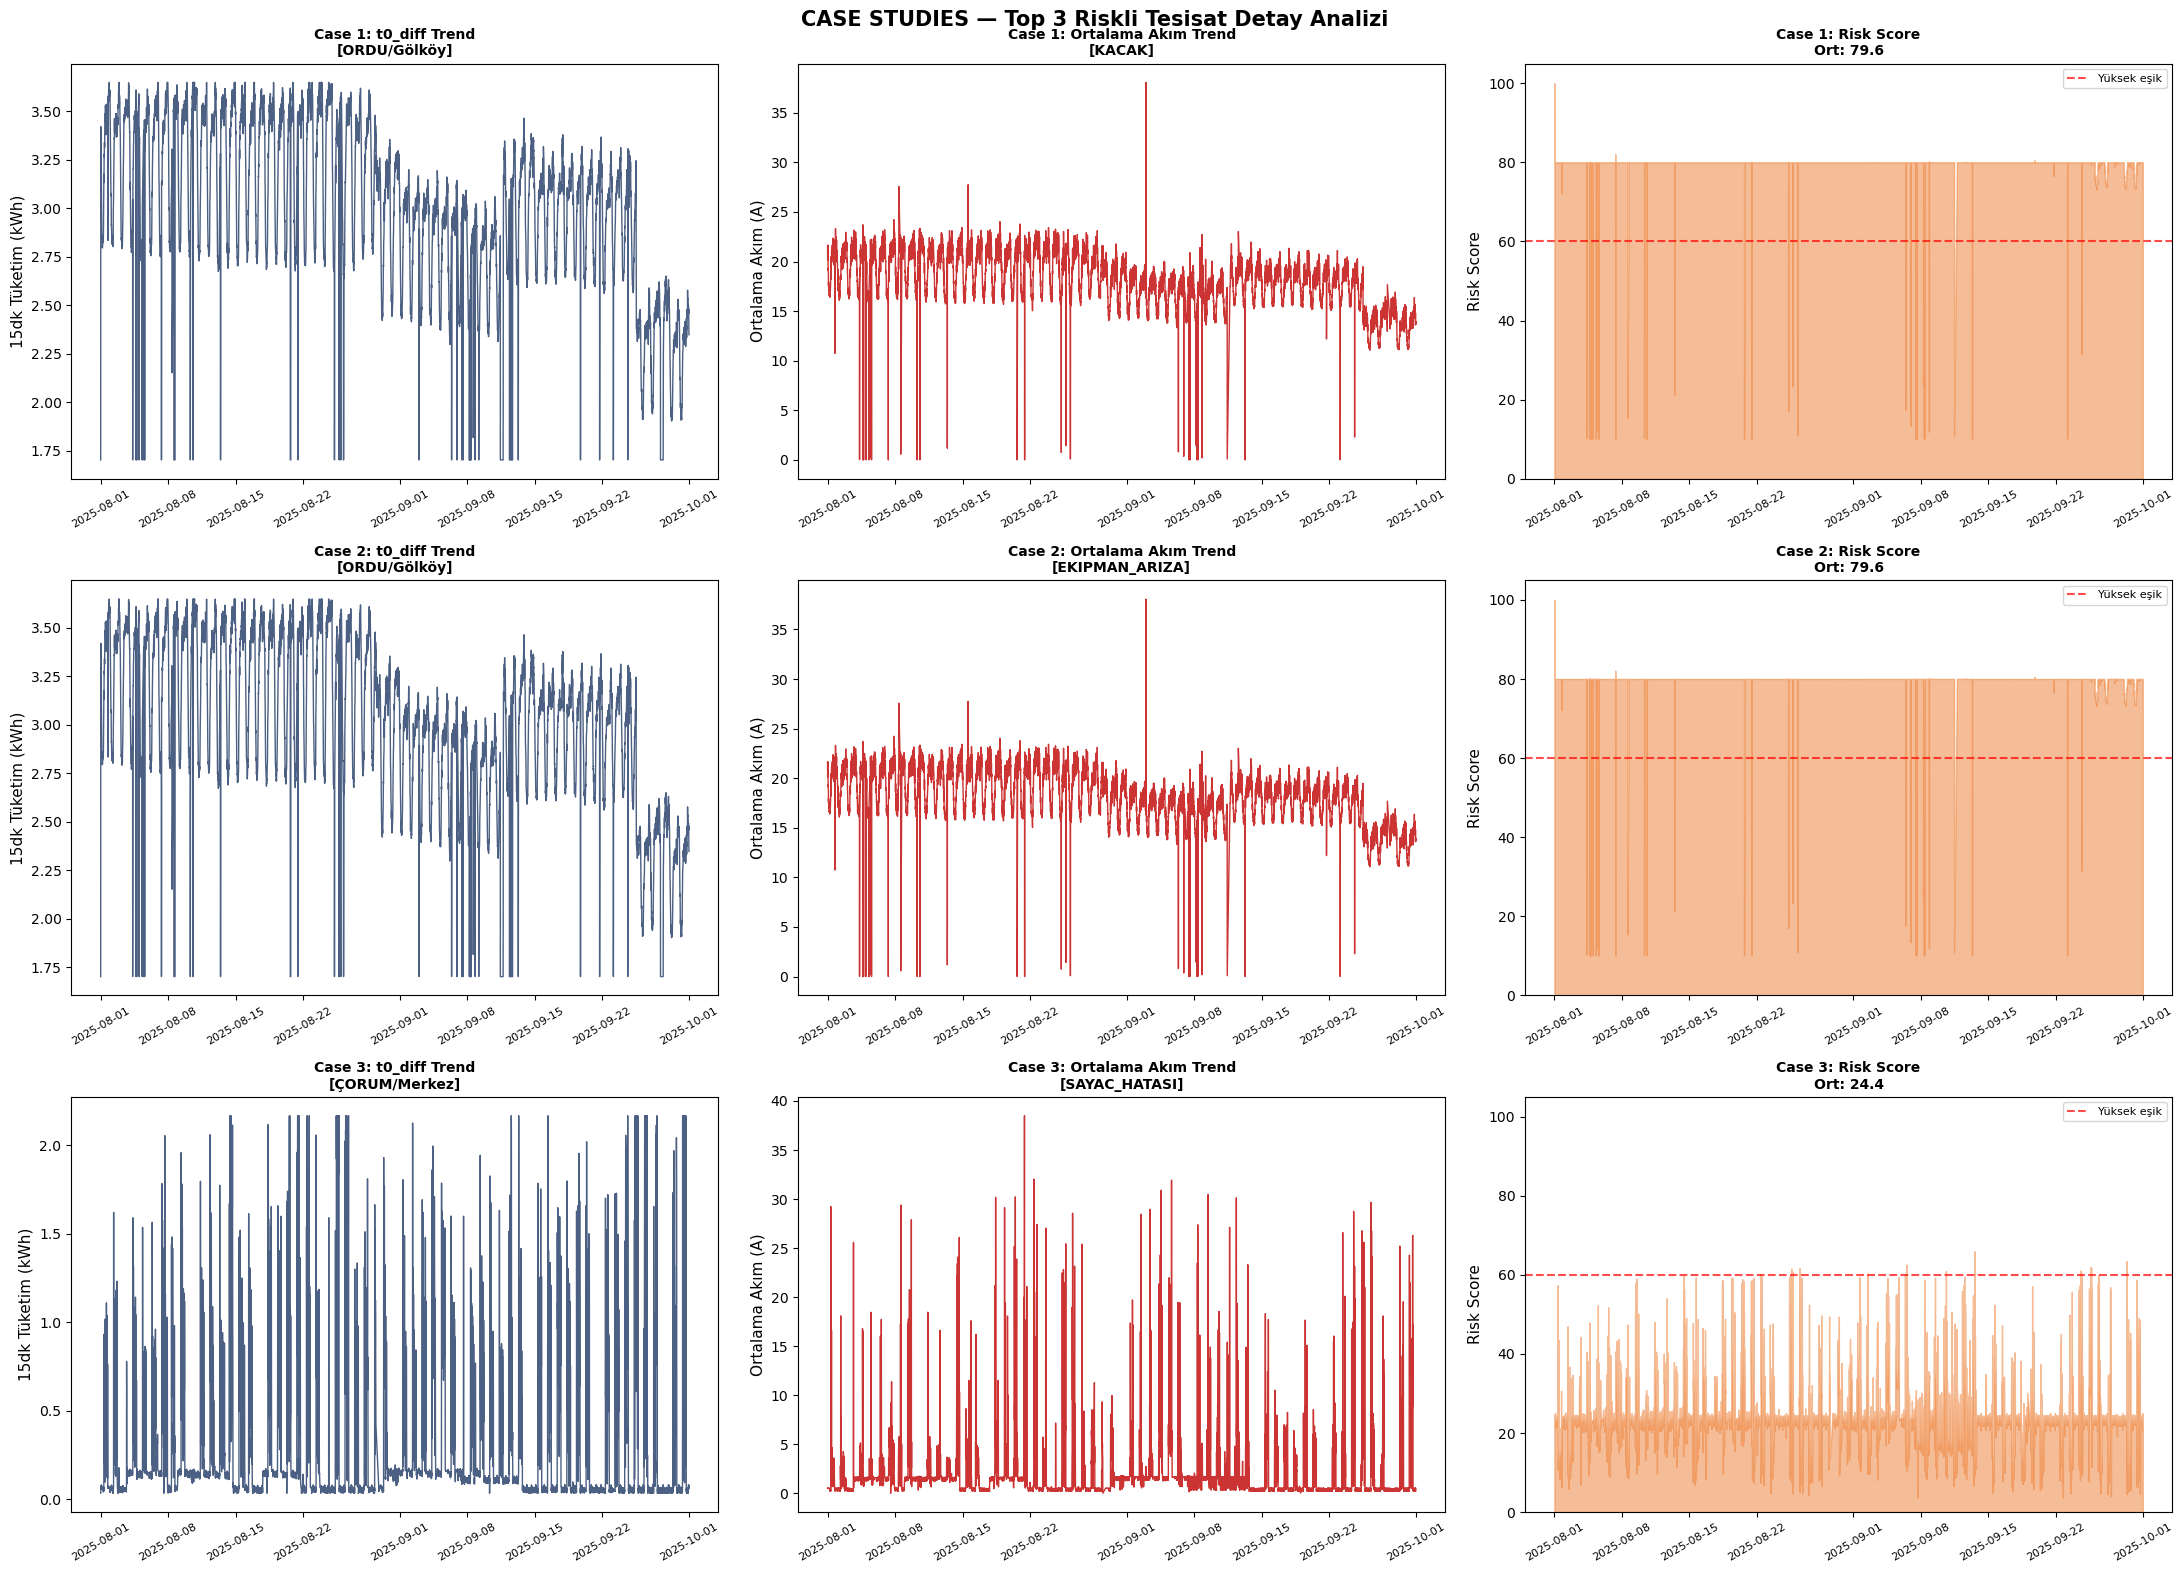

case_studies_summary.csv kaydedildi


,case_no,tesisat_no_id,il_ilce,anomaly_type,ort_risk_score,risk_reason
0,1,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU/Gölköy,kacak,79.5700,"Akım yüksek, tüketim düşük. Olası kaçak kullan..."
1,2,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU/Gölköy,ekipman_ariza,79.5700,"Akım yüksek, tüketim düşük. Olası kaçak kullan..."
2,3,48e385a3937042548a91f819b3cf1f53,ÇORUM/Merkez,sayac_hatasi,24.3600,Normal ölçüm aralığında.


In [68]:
fig, axes = plt.subplots(3, 3, figsize=(22, 16))
case_summaries = []

for idx, row in top3_df.iterrows():
    tid   = row['tesisat_no_id']
    atype = row['anomaly_type']

    tdf = df_scored[df_scored['tesisat_no_id'] == tid].sort_values('load_profile_date')

    meta = tdf.iloc[0]
    il, ilce = meta['il'], meta['ilce']
    abone_grubu = meta['abone_grubu']
    marka_model = f"{meta['marka']} {meta['model']}"
    ort_risk = tdf['risk_score'].mean()
    reason   = tdf['risk_reason'].iloc[0]

    t0d_plot = tdf['t0_diff'].clip(
        tdf['t0_diff'].quantile(0.01),
        tdf['t0_diff'].quantile(0.99)
    )
    axes[idx, 0].plot(tdf['load_profile_date'], t0d_plot,
                      color=PALETTE[0], linewidth=1, alpha=0.8)
    axes[idx, 0].set_title(f'Case {idx+1}: t0_diff Trend\n[{il}/{ilce}]',
                           fontweight='bold', fontsize=10)
    axes[idx, 0].set_ylabel('15dk Tüketim (kWh)')
    plt.setp(axes[idx, 0].xaxis.get_majorticklabels(), rotation=30, fontsize=8)

    axes[idx, 1].plot(tdf['load_profile_date'], tdf['avg_current'],
                      color=PALETTE[2], linewidth=1, alpha=0.8)
    axes[idx, 1].set_title(f'Case {idx+1}: Ortalama Akım Trend\n[{atype.upper()}]',
                           fontweight='bold', fontsize=10)
    axes[idx, 1].set_ylabel('Ortalama Akım (A)')
    plt.setp(axes[idx, 1].xaxis.get_majorticklabels(), rotation=30, fontsize=8)

    axes[idx, 2].fill_between(tdf['load_profile_date'], tdf['risk_score'],
                               color=PALETTE[3], alpha=0.5)
    axes[idx, 2].axhline(60, color='red', linestyle='--', alpha=0.7, label='Yüksek eşik')
    axes[idx, 2].set_title(f'Case {idx+1}: Risk Score\nOrt: {ort_risk:.1f}',
                           fontweight='bold', fontsize=10)
    axes[idx, 2].set_ylabel('Risk Score')
    axes[idx, 2].set_ylim(0, 105)
    axes[idx, 2].legend(fontsize=8)
    plt.setp(axes[idx, 2].xaxis.get_majorticklabels(), rotation=30, fontsize=8)

    case_summaries.append({
        'case_no'          : idx + 1,
        'tesisat_no_id'    : tid,
        'il_ilce'          : f'{il}/{ilce}',
        'abone_grubu'      : abone_grubu,
        'sayac'            : marka_model,
        'anomaly_type'     : atype,
        'ort_risk_score'   : round(ort_risk, 2),
        'risk_reason'      : reason,
        'kayit_sayisi'     : len(tdf),
    })

plt.suptitle('CASE STUDIES — Top 3 Riskli Tesisat Detay Analizi',
             fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig(EDA_OUT / 'case_studies.png', dpi=150, bbox_inches='tight')
plt.show()

case_df = pd.DataFrame(case_summaries)
case_df.to_csv(EDA_OUT / 'case_studies_summary.csv', index=False)
print('case_studies_summary.csv kaydedildi')
display(case_df[['case_no','tesisat_no_id','il_ilce','anomaly_type',
                 'ort_risk_score','risk_reason']])

## 10. Operational Insights

In [80]:
conn = sqlite3.connect(':memory:')
df_scored.to_sql('final_dataset', conn, if_exists='replace', index=False)

action_query = """
SELECT
    tesisat_no_id,
    il,
    ilce,
    anomaly_type,
    ROUND(AVG(risk_score), 2) AS ort_risk_score,
    risk_reason
FROM final_dataset
WHERE anomaly_type != 'normal'
GROUP BY tesisat_no_id, il, ilce, anomaly_type, risk_reason
ORDER BY ort_risk_score DESC
LIMIT 10;
"""

top10_action = pd.read_sql(action_query, conn)
conn.close()

display(top10_action)

,tesisat_no_id,il,ilce,anomaly_type,ort_risk_score,risk_reason
0,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,kacak,100.0000,"Akım yüksek, tüketim düşük. Olası kaçak kullan..."
1,d7a38b85cd1c4238a10bd6182d8978b1,SAMSUN,Havza,kacak,100.0000,"Akım yüksek, tüketim düşük. Olası kaçak kullan..."
2,79567eafb552482e9d30cbd74eb5a67b,SİNOP,Ayancık,kacak,90.0000,"Akım yüksek, tüketim düşük. Olası kaçak kullanım."
3,a25e6e8c19b14740808305465b1de6c0,SAMSUN,Bafra,ekipman_ariza,85.4700,Faz dengesizliği ve yüksek akım. Ekipman arıza...
4,c9f2af7c4ce14fe386bc97ab2867d762,SAMSUN,İlkadım,ekipman_ariza,79.9600,Faz dengesizliği ve yüksek akım. Ekipman arıza...
5,208e38ba076e428c9e5c9d9c0bd53f3f,ORDU,Gölköy,ekipman_ariza,79.9200,Faz dengesizliği ve yüksek akım. Ekipman arıza...
6,d7a38b85cd1c4238a10bd6182d8978b1,SAMSUN,Havza,ekipman_ariza,79.4000,Faz dengesizliği ve yüksek akım. Ekipman arıza...
7,b4f5c124eae64882a39d56433599fddf,SİNOP,Ayancık,ekipman_ariza,78.6700,Faz dengesizliği ve yüksek akım. Ekipman arıza...
8,a895b42f51f545468fb948b6c3890a44,ÇORUM,Sungurlu,kacak,77.7800,"Akım yüksek, tüketim düşük. Olası kaçak kullanım."
9,79567eafb552482e9d30cbd74eb5a67b,SİNOP,Ayancık,ekipman_ariza,72.9100,Faz dengesizliği ve yüksek akım. Ekipman arıza...


In [81]:
dominant_il = (
    df_scored[df_scored['anomaly_type'] != 'normal']
    .groupby(['il', 'ilce'])['risk_score']
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
)

dominant_type = (
    df_scored[df_scored['anomaly_type'] != 'normal']['anomaly_type']
    .value_counts()
    .idxmax()
)

high_risk_count = (df_scored['risk_bucket'] == 'High').sum()

missing_v_high = (
    df_scored.groupby('ilce')['v_missing_flag']
    .mean()
    .sort_values(ascending=False)
    .head(3)
)

operational_summary = {
    "Baskın Anomali Türü": dominant_type,
    "Yüksek Riskli Kayıt": high_risk_count,
    "En Riskli Bölge 1": f"{dominant_il.iloc[0]['il']}/{dominant_il.iloc[0]['ilce']}",
    "En Riskli Bölge 2": f"{dominant_il.iloc[1]['il']}/{dominant_il.iloc[1]['ilce']}" if len(dominant_il) > 1 else "-",
    "Gerilim Eksikliği En Yüksek İlçe": missing_v_high.index[0]
}

pd.DataFrame(operational_summary.items(), columns=["Metric", "Value"])

,Metric,Value
0,Baskın Anomali Türü,suspicious
1,Yüksek Riskli Kayıt,30370
2,En Riskli Bölge 1,ORDU/Gölköy
3,En Riskli Bölge 2,SAMSUN/Havza
4,Gerilim Eksikliği En Yüksek İlçe,Atakum


The anomaly detection framework successfully filtered a large measurement dataset and highlighted a limited number of installations with elevated operational risk.

Analysis of approximately 354K load profile records identified nearly 93K records with anomaly signals, while around 30K records were classified as high-risk according to the risk scoring framework. Although the majority of records fall into the normal category, the model isolates a small subset of installations that require operational attention.

### Key Technical Findings

1. Equipment-related anomalies dominate the anomaly set.  
   The most common anomaly pattern is associated with phase imbalance and high current, which strongly indicates potential equipment malfunction or connection issues.

2. Voltage absence combined with continued consumption is a critical signal. 
   Several installations show missing voltage measurements while energy consumption continues, suggesting potential:
   - measurement infrastructure faults
   - meter misconfiguration
   - illegal or bypassed connections.

3. Phase-zero anomalies are regionally concentrated.  
   Regional analysis reveals that certain provinces and districts exhibit higher concentrations of phase-zero events, which may indicate distribution network imbalance or local infrastructure problems.

4. Suspicious installations exhibit abnormal current–consumption relationships.  
   Cases where current remains high while consumption appears low represent potential electricity theft or metering inconsistencies.

### Operational Interpretation

From an operational perspective, the model does not simply generate large volumes of alarms; instead, it prioritizes a manageable number of installations with the strongest technical signals. This selectivity increases the usability of the model for field operations.

### Recommended Operational Actions

Based on the detected anomaly patterns, the following operational priorities are recommended:

1. Field inspection of high-risk installations  
The installations with the highest risk scores should be inspected on-site to verify meter integrity, connections, and phase balance conditions.

2. Meter validation and calibration checks  
Installations exhibiting voltage absence or abnormal reactive ratios should undergo meter diagnostics to detect possible measurement errors.

3. Infrastructure and connection review 
Locations with repeated phase imbalance signals may require infrastructure checks such as transformer balancing or phase connection verification.

By focusing on these prioritized installations, operational teams can reduce investigation time, improve network reliability, and detect potential losses more efficiently.

## 11. Executive Summary

In [82]:
n_tesisat    = df_scored['tesisat_no_id'].nunique()
n_kayit      = len(df_scored)
n_anomali    = (df_scored['anomaly_type'] != 'normal').sum()
oran_anomali = round(n_anomali / n_kayit * 100, 2)

n_kacak      = (df_scored['anomaly_type'] == 'kacak').sum()
n_ekipman    = (df_scored['anomaly_type'] == 'ekipman_ariza').sum()
n_sayac      = (df_scored['anomaly_type'] == 'sayac_hatasi').sum()

n_high       = (df_scored['risk_bucket'] == 'High').sum()

n_faz_sifir  = (df_scored['phase_zero_flag'] == 1).sum()
n_volt_miss  = df_scored['voltage_missing_consumption_flag'].sum()

summary = {
    "Tesisat Sayısı": n_tesisat,
    "Toplam Kayıt": n_kayit,
    "Anomali Sayısı": n_anomali,
    "Anomali Oranı (%)": oran_anomali,
    "Kaçak Anomali": n_kacak,
    "Ekipman Arıza Anomali": n_ekipman,
    "Sayaç Hatası Anomali": n_sayac,
    "Yüksek Risk Kayıt": n_high,
    "Faz Sıfır Anomali": n_faz_sifir,
    "Gerilim Eksik Tüketim": n_volt_miss
}

summary

{'Tesisat Sayısı': 74,
 'Toplam Kayıt': 353949,
 'Anomali Sayısı': np.int64(93238),
 'Anomali Oranı (%)': np.float64(26.34),
 'Kaçak Anomali': np.int64(8),
 'Ekipman Arıza Anomali': np.int64(33876),
 'Sayaç Hatası Anomali': np.int64(103),
 'Yüksek Risk Kayıt': np.int64(30370),
 'Faz Sıfır Anomali': np.int64(108077),
 'Gerilim Eksik Tüketim': np.int64(75344)}

This analysis evaluated load profile measurements and technical signals to identify anomalous electricity consumption patterns and operational risks across installations.

A dataset containing approximately 354 thousand measurement records was analyzed using a rule-based anomaly detection and risk scoring framework. The model detected around 93 thousand anomalous records, with approximately 30 thousand classified as high-risk observations requiring further investigation.

The anomaly distribution shows that equipment-related anomalies (phase imbalance and abnormal current levels) represent the dominant technical issue. Additional anomaly signals include suspicious consumption behavior, meter inconsistencies, and rare but critical electricity theft indicators.

Regional analysis indicates that anomaly signals are not evenly distributed across the network, with several districts exhibiting higher concentrations of technical anomalies. These regional clusters highlight potential local infrastructure or measurement system problems.

Technical signal analysis also revealed frequent occurrences of:

- phase-zero events
- missing voltage measurements with ongoing consumption
- abnormal current–consumption relationships

These signals strengthen the likelihood of equipment malfunction, metering problems, or potential energy losses.

Overall, the model successfully narrows down a large dataset into a prioritized set of installations requiring operational attention, enabling more targeted field inspections.

### Recommended Actions

1. Prioritize field inspection for high-risk installations** identified by the model.
2. Perform meter validation and diagnostic checks** on installations showing voltage anomalies or abnormal reactive ratios.
3. Review network infrastructure and phase connections** in regions with concentrated phase imbalance signals.

Implementing these actions can help improve measurement reliability, reduce operational risk, and support early detection of potential electricity losses.